(ch_clustering)=
# Clustering

**Clustering** (or *cluster analysis*) is the process of organizing a collection of data points into groups, referred to as **clusters**, such that points within the same cluster are more similar to each other than to points in other clusters. Clustering is one of the classic tools of exploratory data analysis, because it can help us detect structure in data even when we do not yet know exactly what we are looking for.

In practice, clustering can be useful in many different situations. It can help us explore data, summarize large datasets, identify subgroups, support anomaly detection, and sometimes serve as a preprocessing step for later analyses. At the same time, clustering is not a single, clearly defined task with one universally correct solution. Different clustering algorithms define clusters in different ways.

## Introduction
### What is clustering?
Clustering aims to divide data points into groups in a meaningful way. Usually, we hope that points within the same cluster share important properties or are close to one another according to some notion of similarity.
In some simple examples, this can look almost trivial. In {numref}`fig_clustering_intro`, most people would probably agree that the points fall naturally into three groups. At least so far, I have not yet had a student answer anything other than "three" when asked how many clusters they see in this dataset.

```{figure} ../images/fig_clustering_intro.png
:name: fig_clustering_intro

Clustering refers to dividing data points into separate groups, called **clusters**.
```

Still, even in such apparently simple situations, there is already an important conceptual point hiding in the background: *what exactly counts as a cluster?* Is it a dense cloud of points? A group around a center? A region separated by empty space from other regions? Different clustering algorithms answer these questions differently.

To make this concrete, let us first create a simple synthetic dataset with three clusters.

In [44]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import colormaps as cmaps  # optional: for some more colormaps

# optional, only to avoid KMeans warning on Windows
import os
os.environ["OMP_NUM_THREADS"] = "1"

# Set the ggplot style (optional)
plt.style.use("ggplot")

In [45]:
clusters = [(15, 0.5, 0.5, 1.5, -0.7),
           (21, 0.8, 0.5, -2.1, -1.2),
           (25, 0.8, 0.7, -2.6, 2.3)]

np.random.seed(42)
data = np.zeros((0, 2))
for (n_points, x_scale, y_scale, x_offset, y_offset) in clusters:
    xpts = np.random.randn(n_points) * x_scale + x_offset
    ypts = np.random.randn(n_points) * y_scale + y_offset
    data = np.vstack((data, np.vstack((xpts, ypts)).T))

We visualize the dataset using pyplot. The dataset contains three visually distinct clusters.

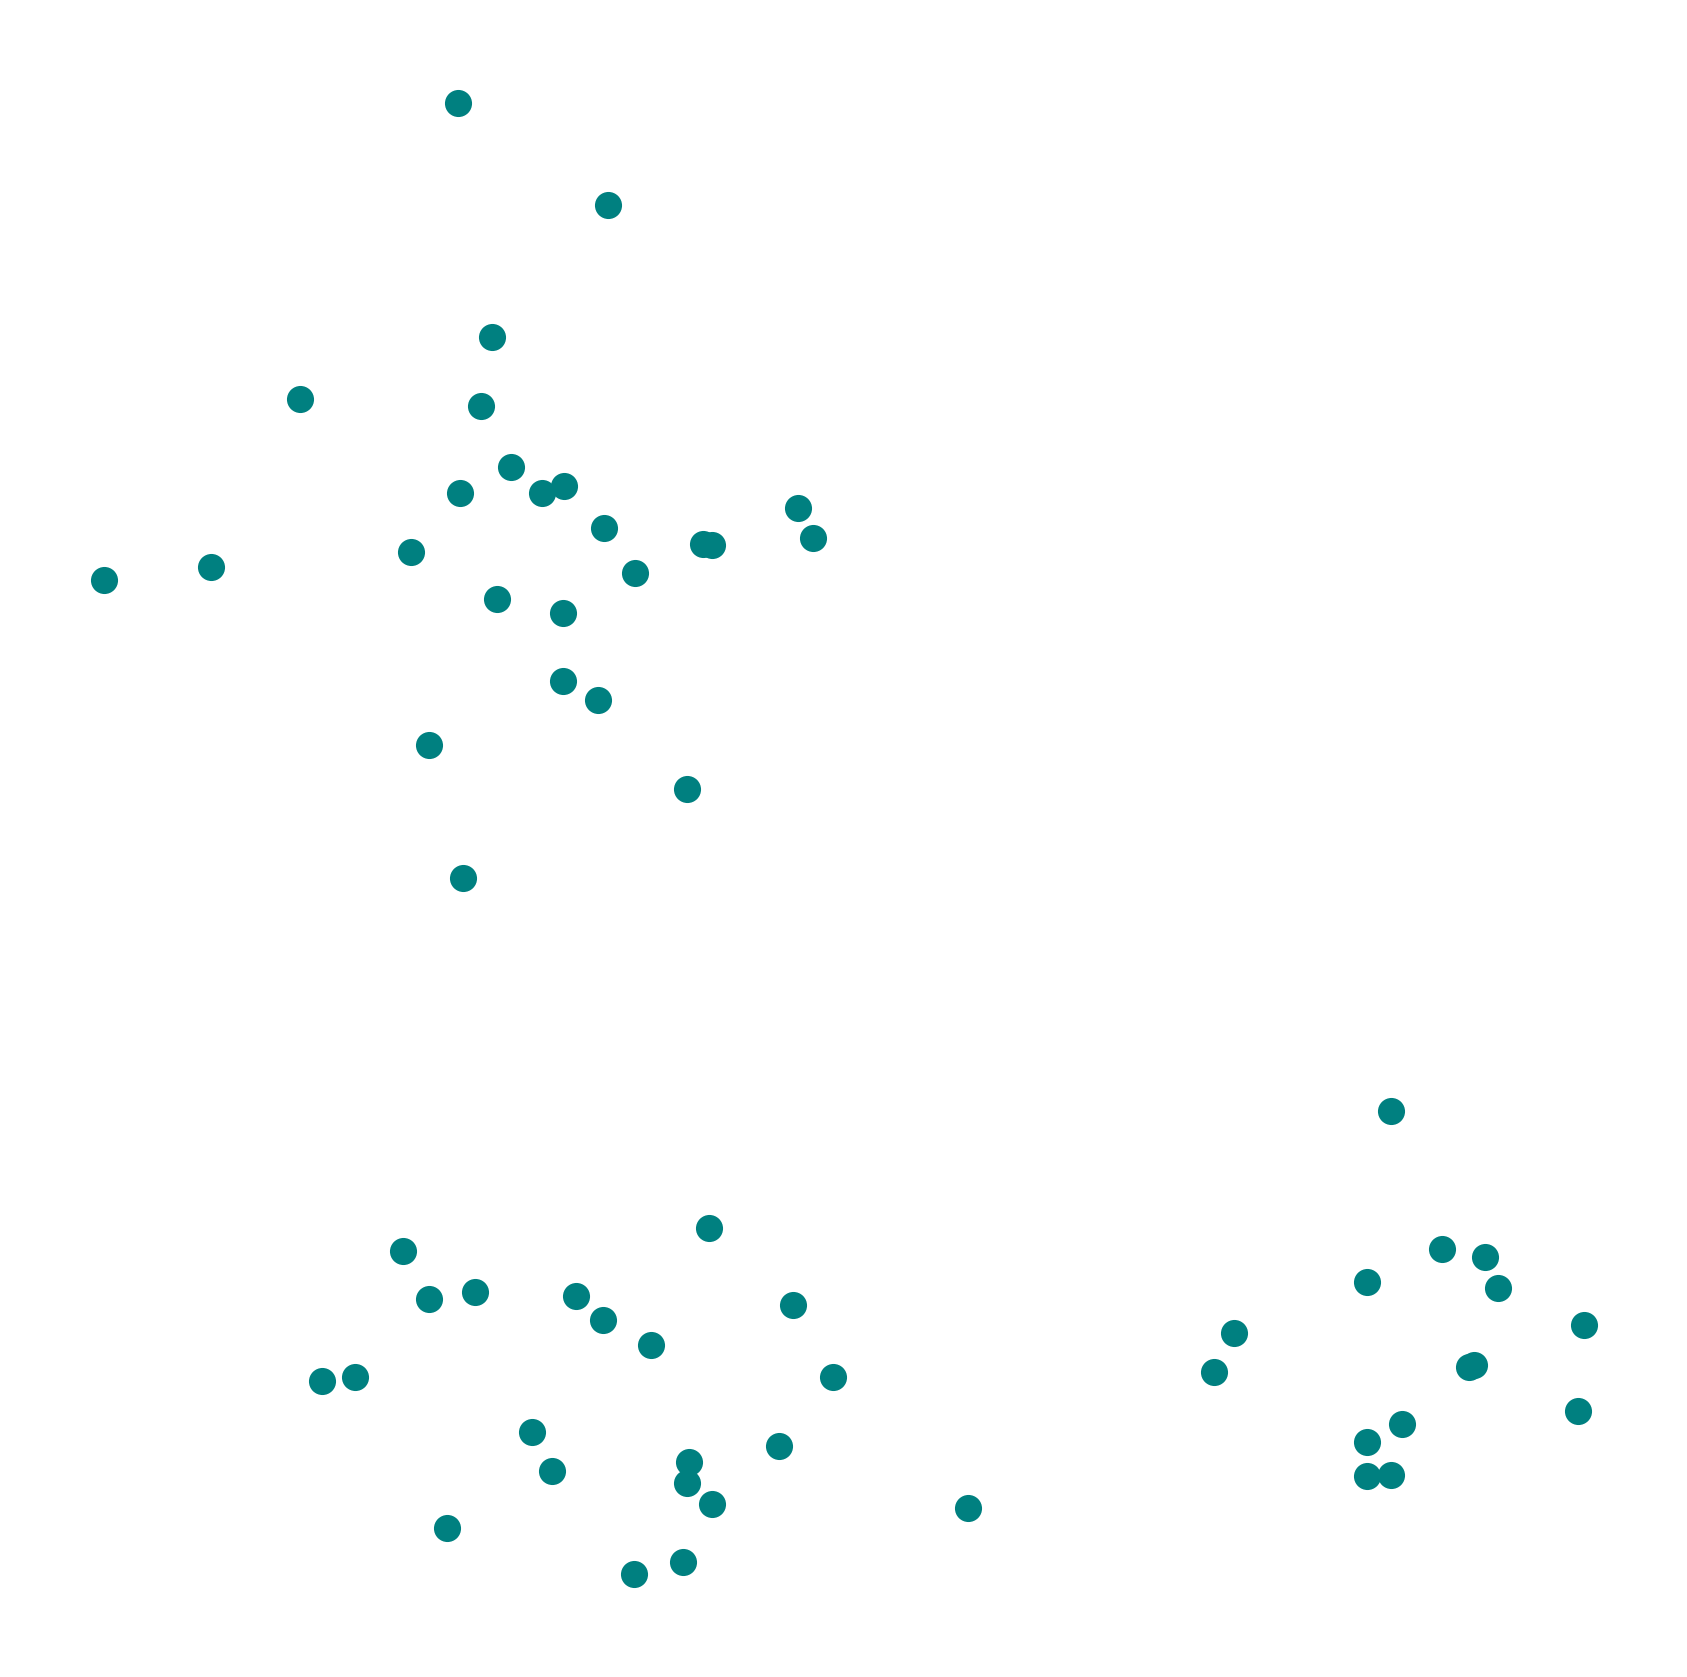

In [46]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

ax.scatter(data[:,0], data[:,1], color="teal")
plt.axis('off')
plt.show()

Assigning the three clusters in this case does not exactly feel like rocket science. We could all do this manually with a pen in no time. So why do we need clustering algorithms at all?

There are at least two important reasons. First, real datasets often do not form such clean and clearly separated groups. Second, and even more importantly, most data is not two-dimensional. The number of features determines the dimensionality of the data, and in practice that is often much larger than two. Once data lives in 5, 10, 50, or 500 dimensions, visual inspection is no longer enough.

This is why we need algorithms: to cluster data systematically, reproducibly, and at a scale that would be impossible to handle manually.

### Why do we want to cluster data?

Clustering is useful for several reasons. One important use is **data exploration**. Clustering can reveal subgroups, structures, and patterns that are not immediately obvious. In many real datasets, this can already provide valuable first insights.

Another common use is **summarization**. A large dataset may be difficult to understand point by point, but easier to reason about when it is divided into a few representative groups. This can be helpful in reporting, visualization, or later model building.

Clustering can also support **anomaly detection**. If most observations form coherent groups, then points that do not fit well into any cluster may deserve special attention. In some applications, those points correspond to errors, fraud, rare events, or otherwise interesting cases. We will see more on this in {ref}`ch_outliers`.

And finally, clustering can sometimes serve as a **preprocessing step**. Once data has been organized into groups, later analyses may become easier or computationally cheaper.

A classic example is **customer segmentation**. Customers with similar behavior or preferences may form useful groups for recommendation systems, communication strategies, or product development. But similar ideas also occur in biology, medicine, document analysis, image processing, and many other fields.

### Hard and Soft Clustering

The most common type of clustering is **hard clustering**, where each data point is assigned to one cluster only. O, in some methods, possibly to no cluster at all if it is treated as noise. In **soft clustering**, by contrast, a data point can belong to several clusters with different degrees of membership. An example of soft clustering is shown in {numref}`fig_clustering_hard_soft`.

```{figure} ../images/fig_clustering_hard_soft.png
:name: fig_clustering_hard_soft

Two common approaches to clustering. In **hard clustering**, each element belongs to one cluster only. In **soft clustering**, an element can belong to several clusters with different degrees of membership.
```

In this introductory chapter, unless stated otherwise, we will mainly focus on **hard clustering**. Later, in the next chapter, we will return to soft clustering with Gaussian mixture models.

### Mini-exercise
**Team up with your neighbor (if in class), or try on your own:**
Look again at the data shown in {numref}`fig_clustering_intro`. How would you design an algorithm that automatically assigns each data point to a cluster?

Think about questions such as:

* How could we decide whether two points are “close enough” to belong together?
* Would you look for cluster centers, cluster boundaries, or dense regions?
* How should the algorithm deal with isolated points?

Make a few notes and try to sketch a simple clustering rule or algorithm.

---

**What did you come up with?**

When I ask this question in class, students usually come up with a variety of good ideas. Some propose grouping points by **distance**, some by drawing **boundaries**, and others by looking for **dense regions**. That is exactly the point: there is no single universal notion of what a cluster is. Different clustering algorithms formalize different intuitions.

In the following, we will start with one of the most common and intuitive clustering algorithms: **K-means**.

## KMeans

K-means is a **centroid-based clustering algorithm**. Its central idea is simple: each cluster is represented by a center point, called a **centroid**, and every data point is assigned to the nearest centroid.

### How K-means works

To build an intuition, imagine that we want to sort fruits based on two features such as sweetness and size. Each fruit is a data point, and our goal is to divide the fruits into a fixed number of groups.

The basic K-means procedure looks like this:

The basic K-means procedure looks like this:

1. **Choose the number of clusters**
   First, we decide how many clusters we want. This number is called $K$.

2. **Initialize the centroids**
   We start with $K$ initial center points. In simple versions of the algorithm, these may be chosen randomly from the data ({numref}`fig_kmeans` A).

3. **Assign each point to the nearest centroid**
   Every data point is assigned to the cluster whose centroid is closest. Often, this closeness is measured using the Euclidean distance ({numref}`fig_kmeans` B).

4. **Update the centroids**
   For each cluster, we compute the average position of all points assigned to it. This new average becomes the new centroid ({numref}`fig_kmeans` C).

5. **Repeat**
   We repeat the assignment and update steps until the assignments no longer change much, or until the centroid positions stabilize.

The result is a partition of the data into $K$ clusters.

```{figure} ../images/fig_kmeans_sketch.png
:name: fig_kmeans

Illustration of the K-means clustering process: initialization of centroids, assignment of points to the nearest centroid, update of centroid positions, and repeated iteration until convergence.
```

In more technical terms, K-means tries to find cluster assignments that minimize the distances between data points and their assigned cluster centers.

### K-means on the simple toy dataset

In the following sections, we will make use of the `Scikit-Learn` implementations of several different clustering algorithms. The workflow will therefore look very similar in all cases, with the most notable difference being the main parameters that each algorithm requires. More information on the code implementations can be found on the [Scikit-Learn documentation](https://scikit-learn.org/stable/modules/clustering.html).

We can apply K-means to our synthetic three-cluster dataset as follows:

In [47]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0).fit(data)

We visualize the resulting clustering. Each cluster is shown with a different color.

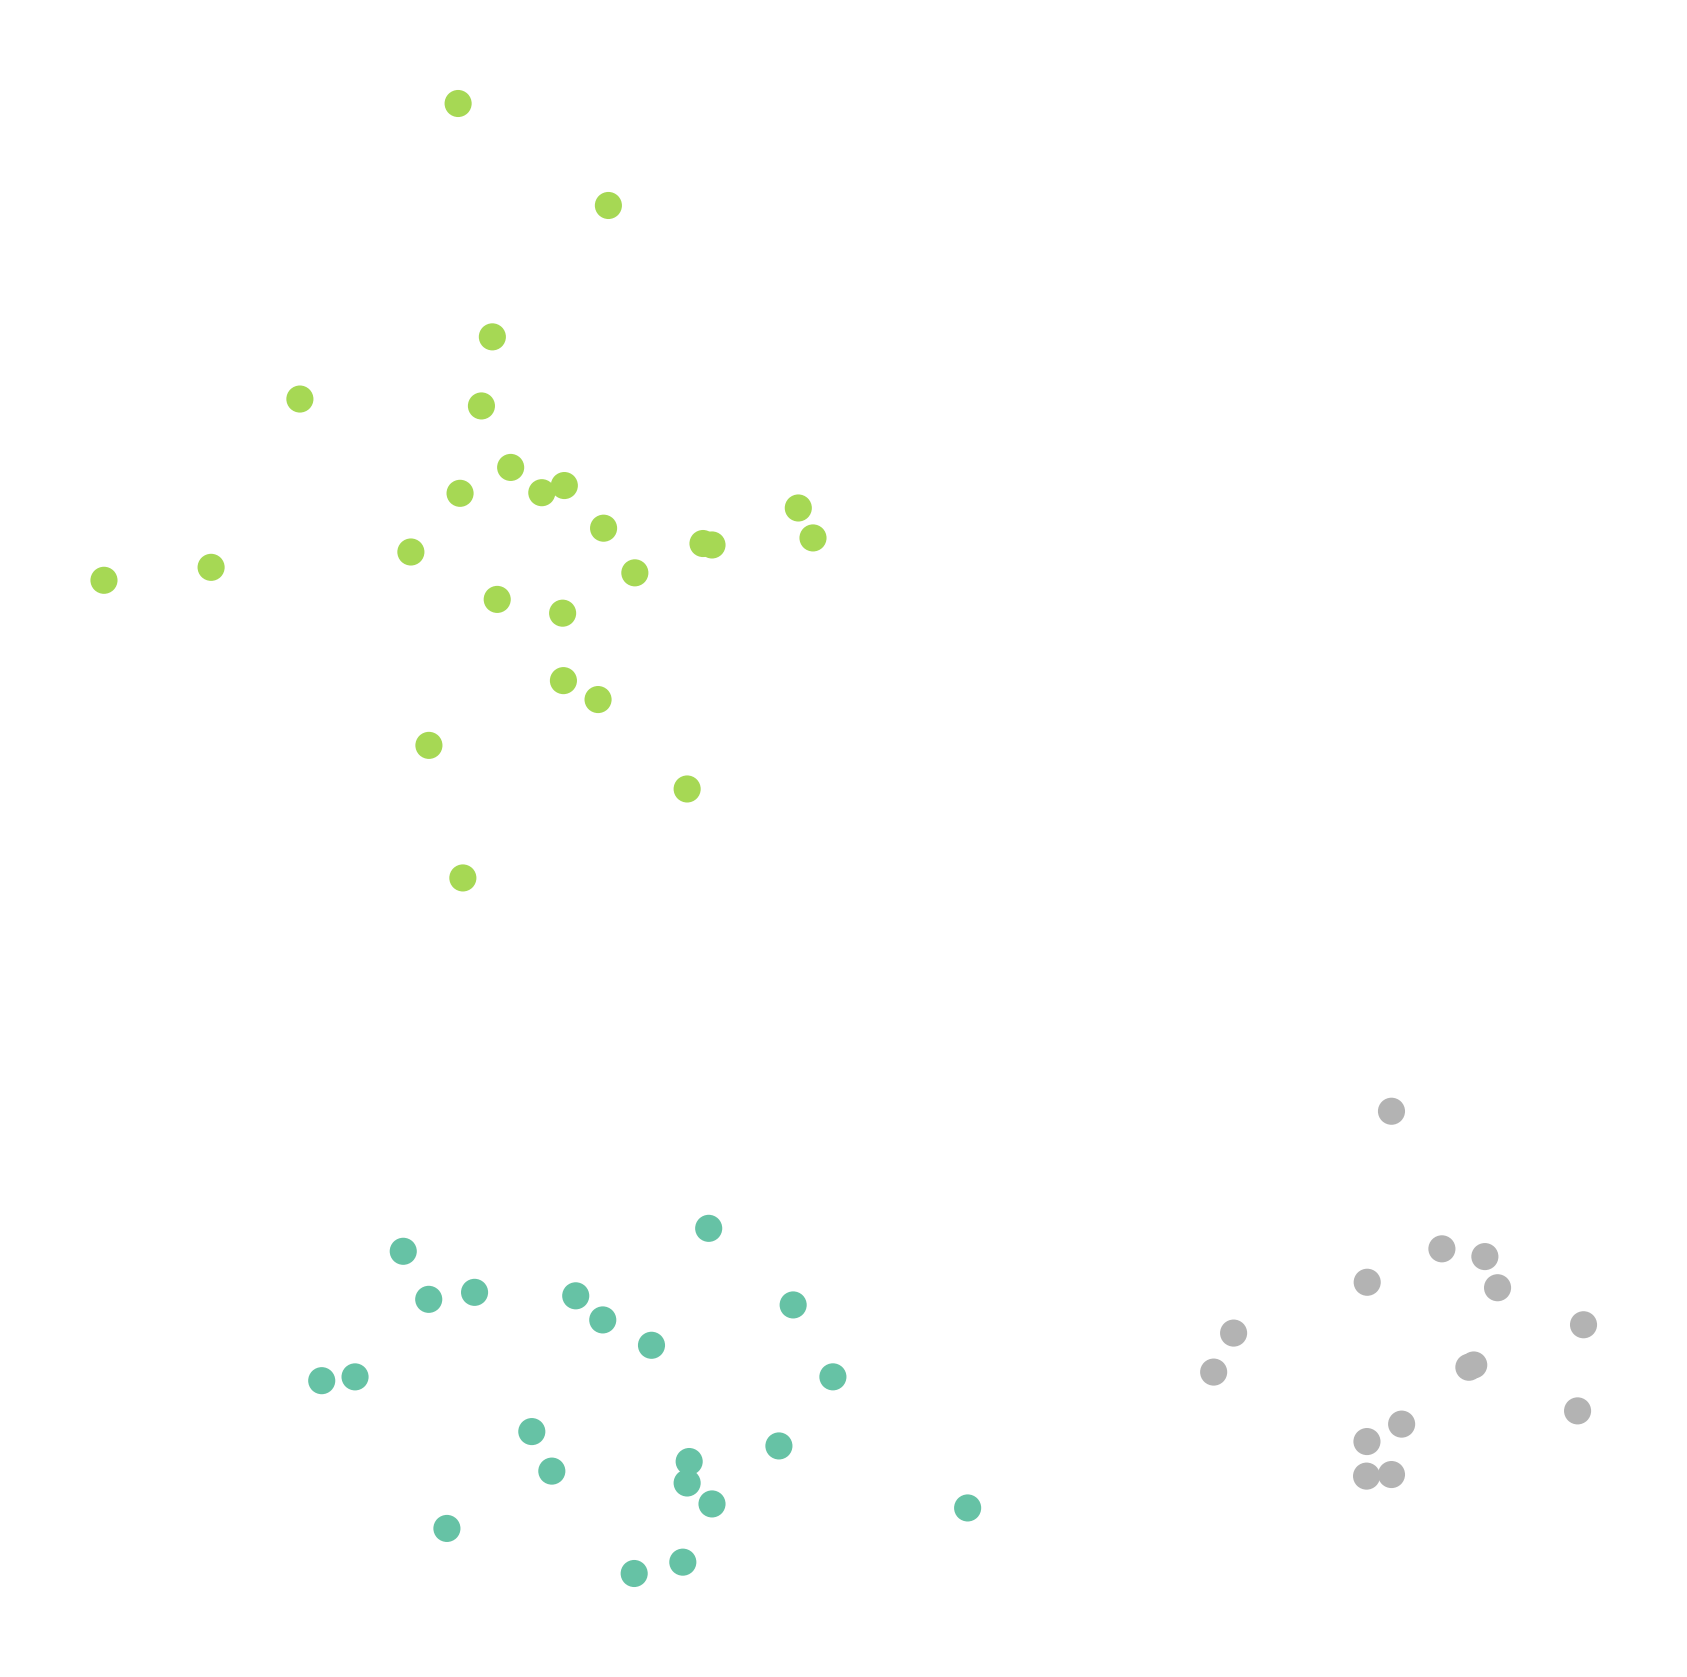

In [34]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

ax.scatter(data[:,0], data[:,1], c=kmeans.labels_, cmap="Set2")
plt.axis("off")
plt.show()

This works very well here. But of course, this is still a very friendly example.

### A slightly more difficult example

The next synthetic dataset is already a bit more realistic. The clusters are less cleanly separated, and the task becomes less obvious.

In [35]:
clusters = [(61, 1, 1.5, 2.5, -0.7),
           (37, 0.8, 0.5, 1.1, -1.2),
           (49, 1.1, 1.2, -2.6, 2.3),
           (44, 0.45, 0.4, 0.5, 2.3),
           (70, 0.9, 0.3, -2.5, -1.7)]

np.random.seed(1)
data = np.zeros((0, 2))
for (n_points, x_scale, y_scale, x_offset, y_offset) in clusters:
    xpts = np.random.randn(n_points) * x_scale + x_offset
    ypts = np.random.randn(n_points) * y_scale + y_offset
    data = np.vstack((data, np.vstack((xpts, ypts)).T))

In [36]:
data.shape

(261, 2)

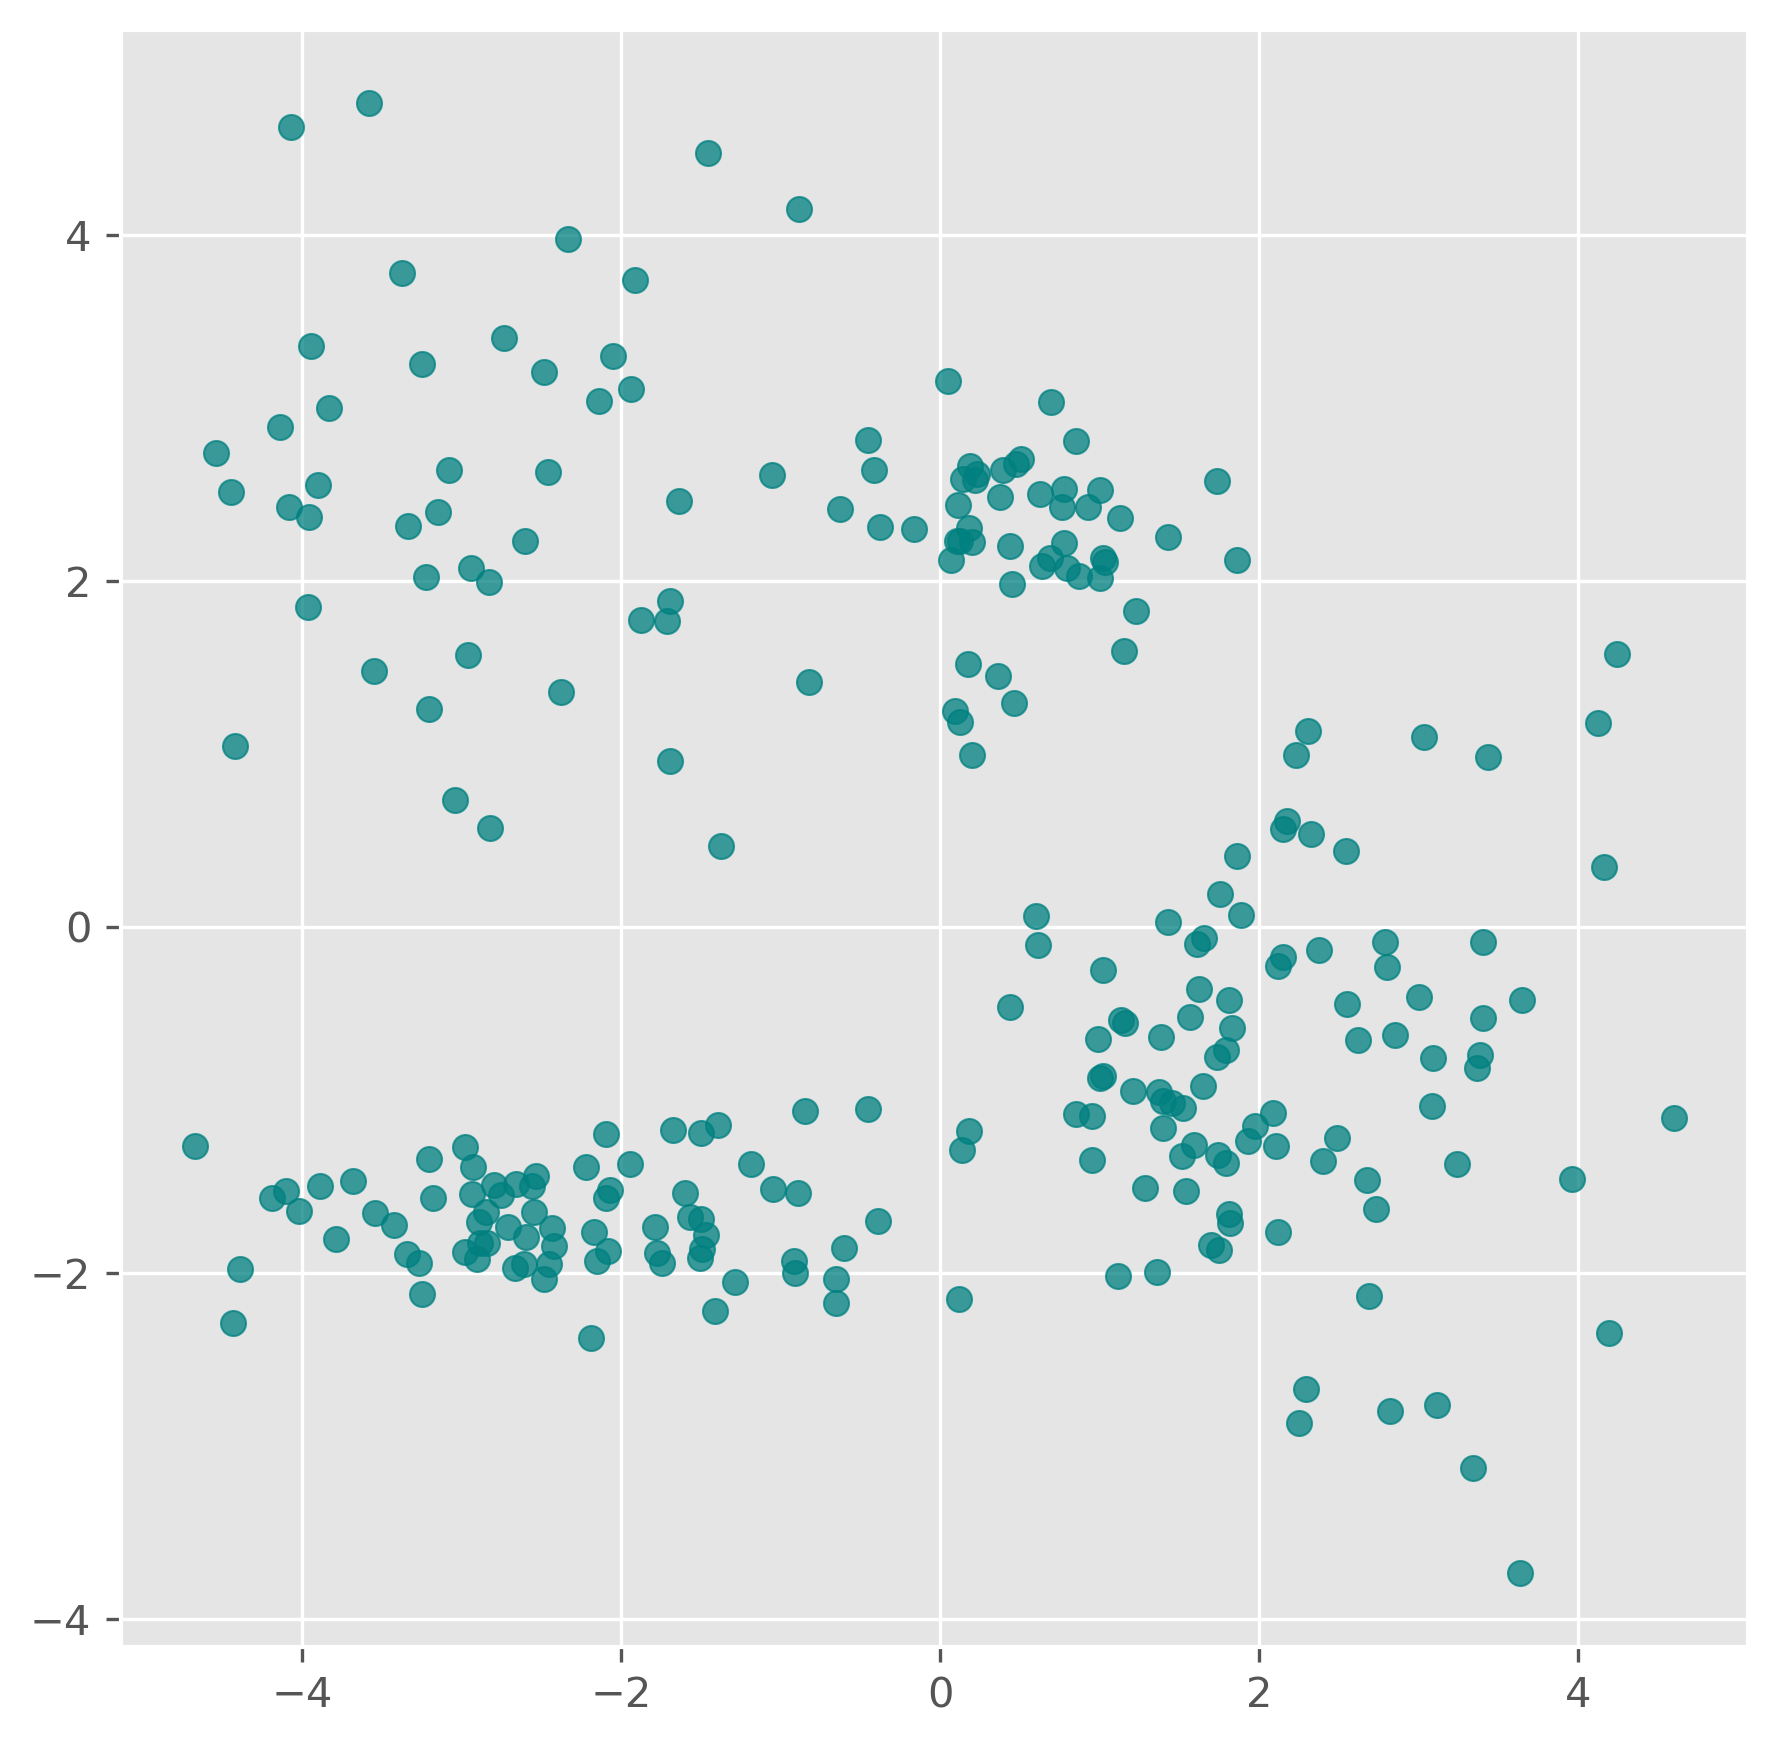

In [37]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

ax.scatter(data[:,0], data[:,1], color="teal", alpha=0.75)
# plt.savefig("example_clustering_01.png", dpi=300, bbox_inches="tight")

In [38]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=0).fit(data)
kmeans.labels_

array([1, 1, 1, 1, 1, 3, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1,
       1, 4, 1, 1, 1, 4, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0,
       0, 3, 0, 0, 4, 0, 0, 0, 0, 0, 3, 0, 3, 0, 3, 0, 0, 3, 0, 0, 0, 0,
       0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 4, 2, 2, 2, 2,
       2, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 2, 4, 4, 2, 2, 2, 2, 4, 4, 2,
       4, 4, 2, 2, 2, 2, 4, 4, 2, 2, 4, 2, 2, 4, 2, 2, 4, 2, 2, 4, 4, 4,
       2, 4, 2, 4, 4, 4, 4, 4, 2, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4],
      dtype=int32)

In [39]:
kmeans.cluster_centers_

array([[-2.99127157,  2.52658441],
       [ 2.17250303, -0.81179254],
       [-3.14602055, -1.70083386],
       [ 0.42175481,  2.27101038],
       [-1.32008432, -1.60712121]])

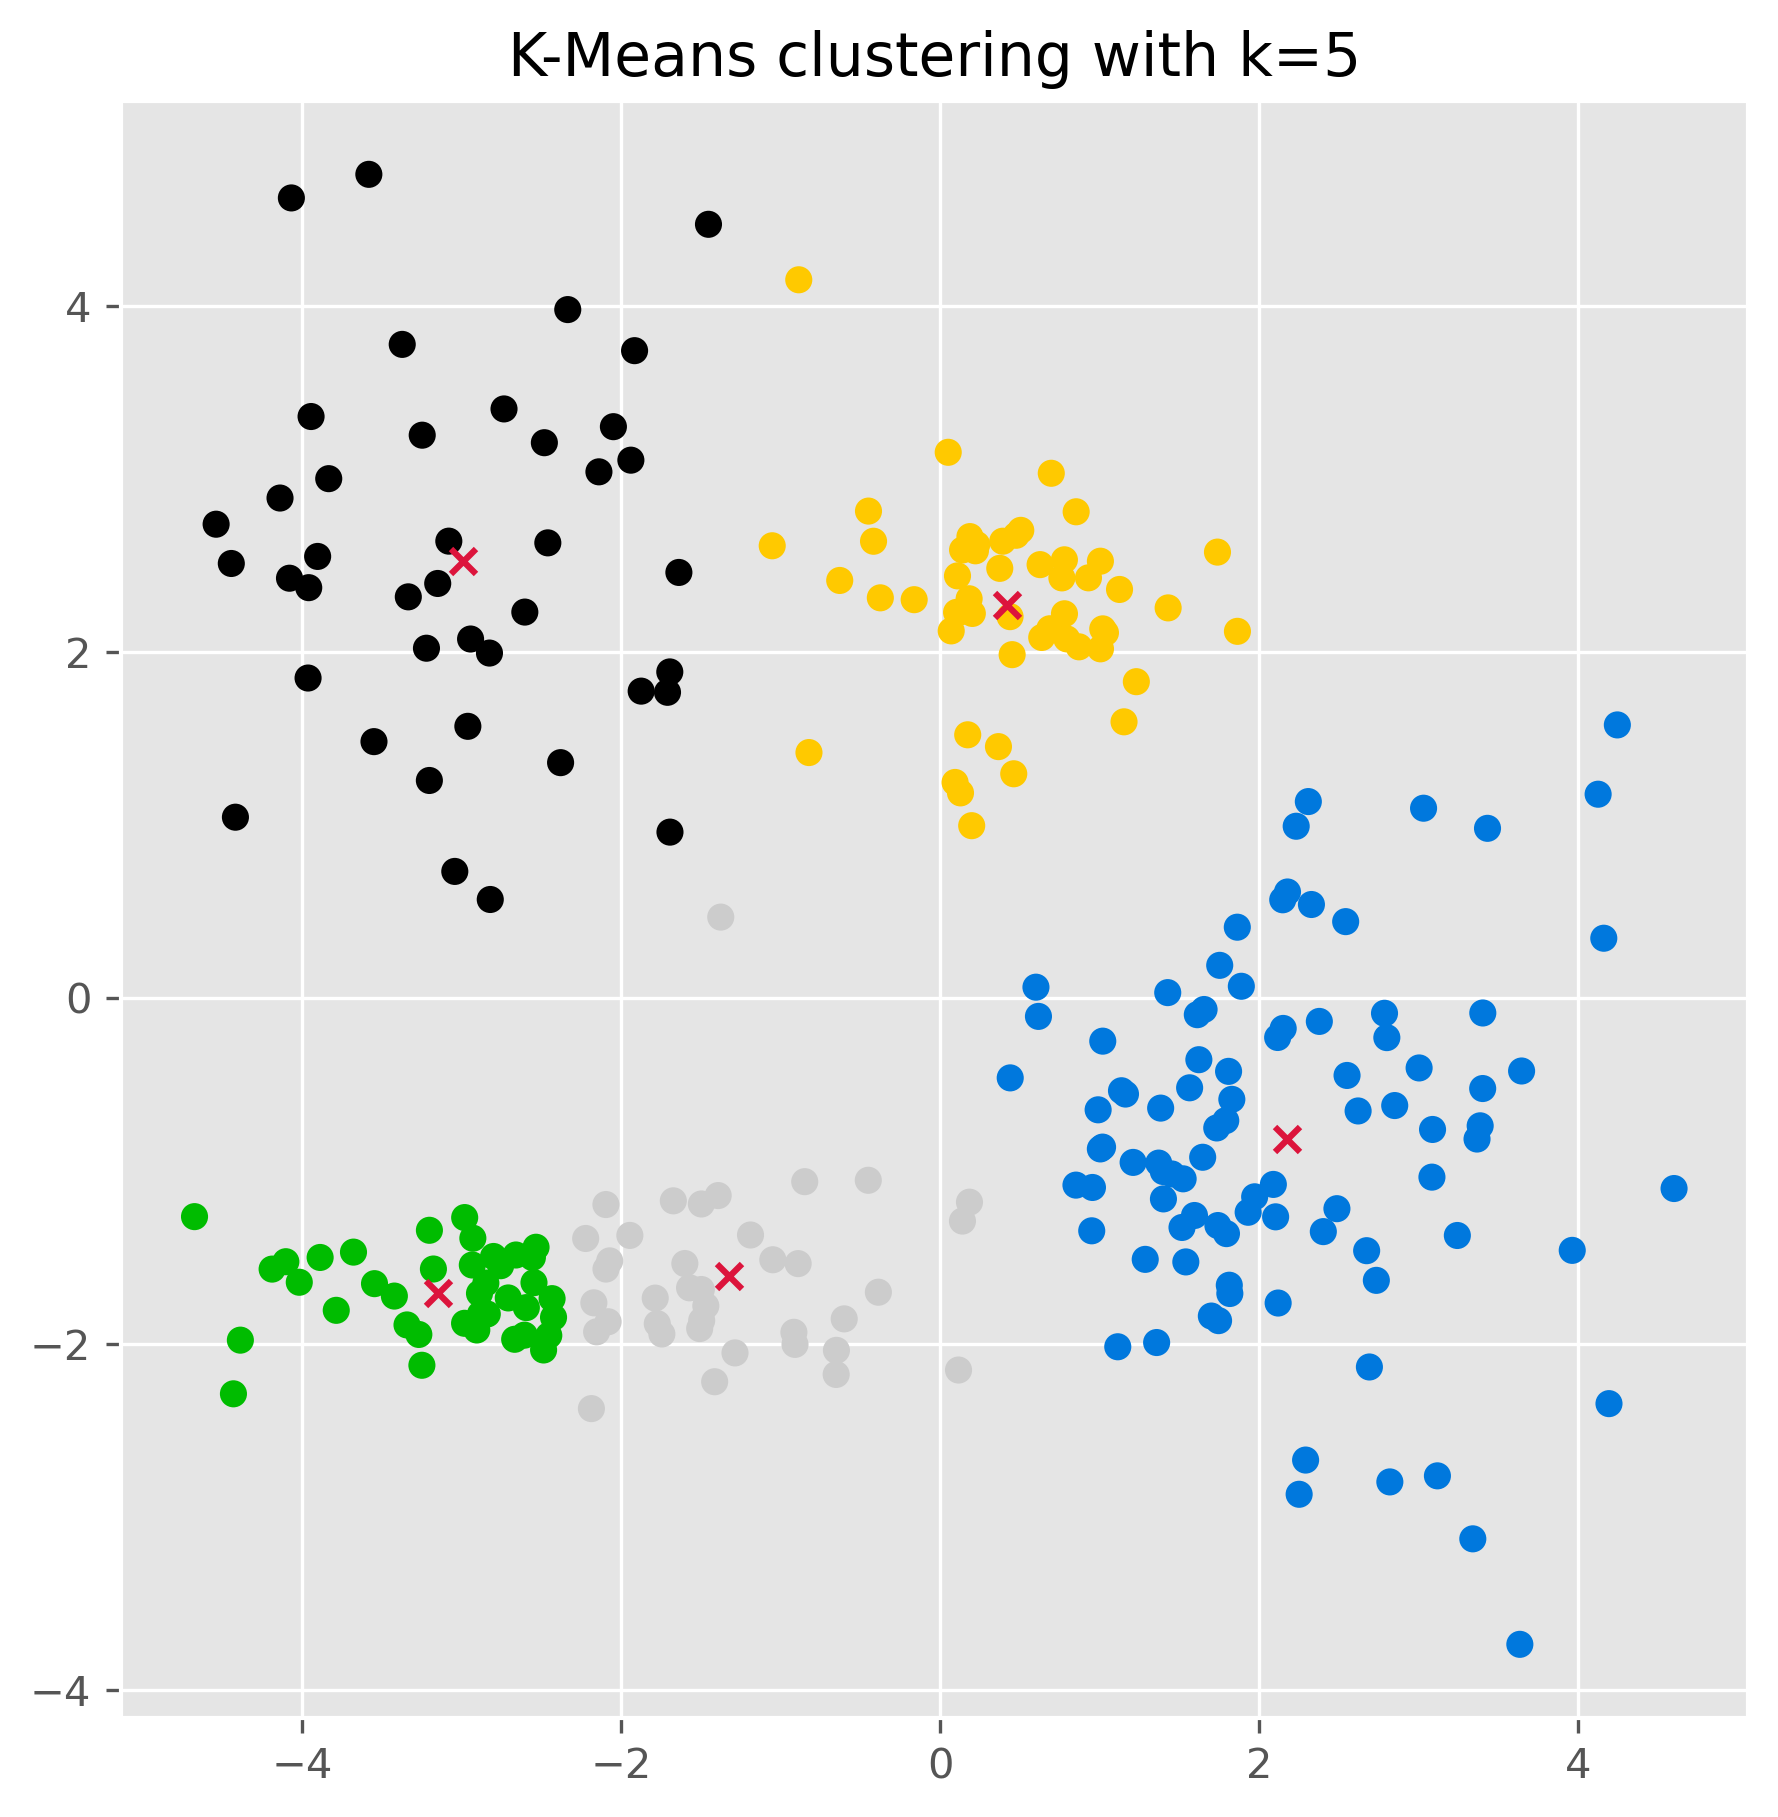

In [40]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

ax.scatter(data[:,0], data[:,1], c=kmeans.labels_, cmap="nipy_spectral")
ax.scatter(kmeans.cluster_centers_[:, 0],
           kmeans.cluster_centers_[:, 1], marker="x", color="crimson")
ax.set_title("K-Means clustering with k=5")
plt.show()

Once the clusters have been found (using the `.fit()` method as done above), we can also use a k-means model to make predctions on unknown datapoints.

In [41]:
kmeans.predict([[-2, 0], [4, 3]])

array([4, 3], dtype=int32)

We can also check the found cluster center points:

In [42]:
kmeans.cluster_centers_

array([[-2.99127157,  2.52658441],
       [ 2.17250303, -0.81179254],
       [-3.14602055, -1.70083386],
       [ 0.42175481,  2.27101038],
       [-1.32008432, -1.60712121]])

### Strengths of K-means

K-means is popular for good reasons. It is relatively easy to understand, easy to implement, and often computationally efficient. For many practical problems, it is a very reasonable first clustering method to try.

It often works well when:

* clusters are compact,
* clusters are roughly round or isotropic,
* and clusters are of similar size.

### Limitations of K-means

K-means is useful, but it comes with important assumptions and limitations.

The first major limitation is that we must specify the number of clusters **beforehand**. In many real problems, we do not know this number in advance. We can try several values of $K$ and compare the results, but there is no universally perfect method for choosing the right value.

A second important limitation is more subtle: K-means works best when clusters are roughly **spherical**, similarly sized, and not too different in density. In other words, it has a fairly specific built-in idea of what a cluster should look like. The scikit-learn example *Demonstration of k-means assumptions* illustrates this point very nicely: K-means works well on simple blob-like clusters, but can struggle when clusters are stretched, have very different variances, or have very unequal sizes [^scikit-learn].

The following variation shows the same idea.

[^scikit-learn]: See also the very nice [demonstration of k-means assumptions in the scikit-learn documentation](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_assumptions.html)

In [48]:
# -----------------------------
# Create four deliberately designed datasets
# -----------------------------

np.random.seed(7)
NUM_PER_CLUSTER = 400

# 1) Three well-separated blob-like clusters
clusters_base = [
    (NUM_PER_CLUSTER, 0.45, 0.45, -3.5,  2.4),
    (NUM_PER_CLUSTER, 0.55, 0.50,  0.0,  3.0),
    (NUM_PER_CLUSTER, 0.50, 0.55,  3.2, -0.3),
]

X_parts = []
y_parts = []
for i, (n_points, x_scale, y_scale, x_offset, y_offset) in enumerate(clusters_base):
    xpts = np.random.randn(n_points) * x_scale + x_offset
    ypts = np.random.randn(n_points) * y_scale + y_offset
    X_parts.append(np.vstack((xpts, ypts)).T)
    y_parts.extend([i] * n_points)

X = np.vstack(X_parts)
y = np.array(y_parts)

# 2) Anisotropic version: stretch and rotate the base dataset
transformation = np.array([[1.0, -0.01],
                           [4.5,  0.08]])
X_aniso = X @ transformation
X_aniso[:, 0] /= 50  # scale

# 3) Unequal variance: two tight, one very spread-out cluster
np.random.seed(11)
clusters_varied = [
    (NUM_PER_CLUSTER, 0.28, 0.28, -1.7,  0.3),
    (2 * NUM_PER_CLUSTER, 0.9, 0.90,  0.2,  2.8),
    (NUM_PER_CLUSTER, 0.25, 0.2,  2.8,  1.4),
]

Xv_parts = []
yv_parts = []
for i, (n_points, x_scale, y_scale, x_offset, y_offset) in enumerate(clusters_varied):
    xpts = np.random.randn(n_points) * x_scale + x_offset
    ypts = np.random.randn(n_points) * y_scale + y_offset
    Xv_parts.append(np.vstack((xpts, ypts)).T)
    yv_parts.extend([i] * n_points)

X_varied = np.vstack(Xv_parts)
y_varied = np.array(yv_parts)

# 4) Unevenly sized clusters: large, medium, and very small cluster
np.random.seed(13)
clusters_filtered = [
    (800, 0.3, 0.30, -0.9,  0.6),
    (100, 0.22, 0.22,  0.0,  1.9),
    ( 20, 0.15, 0.15,  0.9,  1.2),
]

Xf_parts = []
yf_parts = []
for i, (n_points, x_scale, y_scale, x_offset, y_offset) in enumerate(clusters_filtered):
    xpts = np.random.randn(n_points) * x_scale + x_offset
    ypts = np.random.randn(n_points) * y_scale + y_offset
    Xf_parts.append(np.vstack((xpts, ypts)).T)
    yf_parts.extend([i] * n_points)

X_filtered = np.vstack(Xf_parts)
y_filtered = np.array(yf_parts)

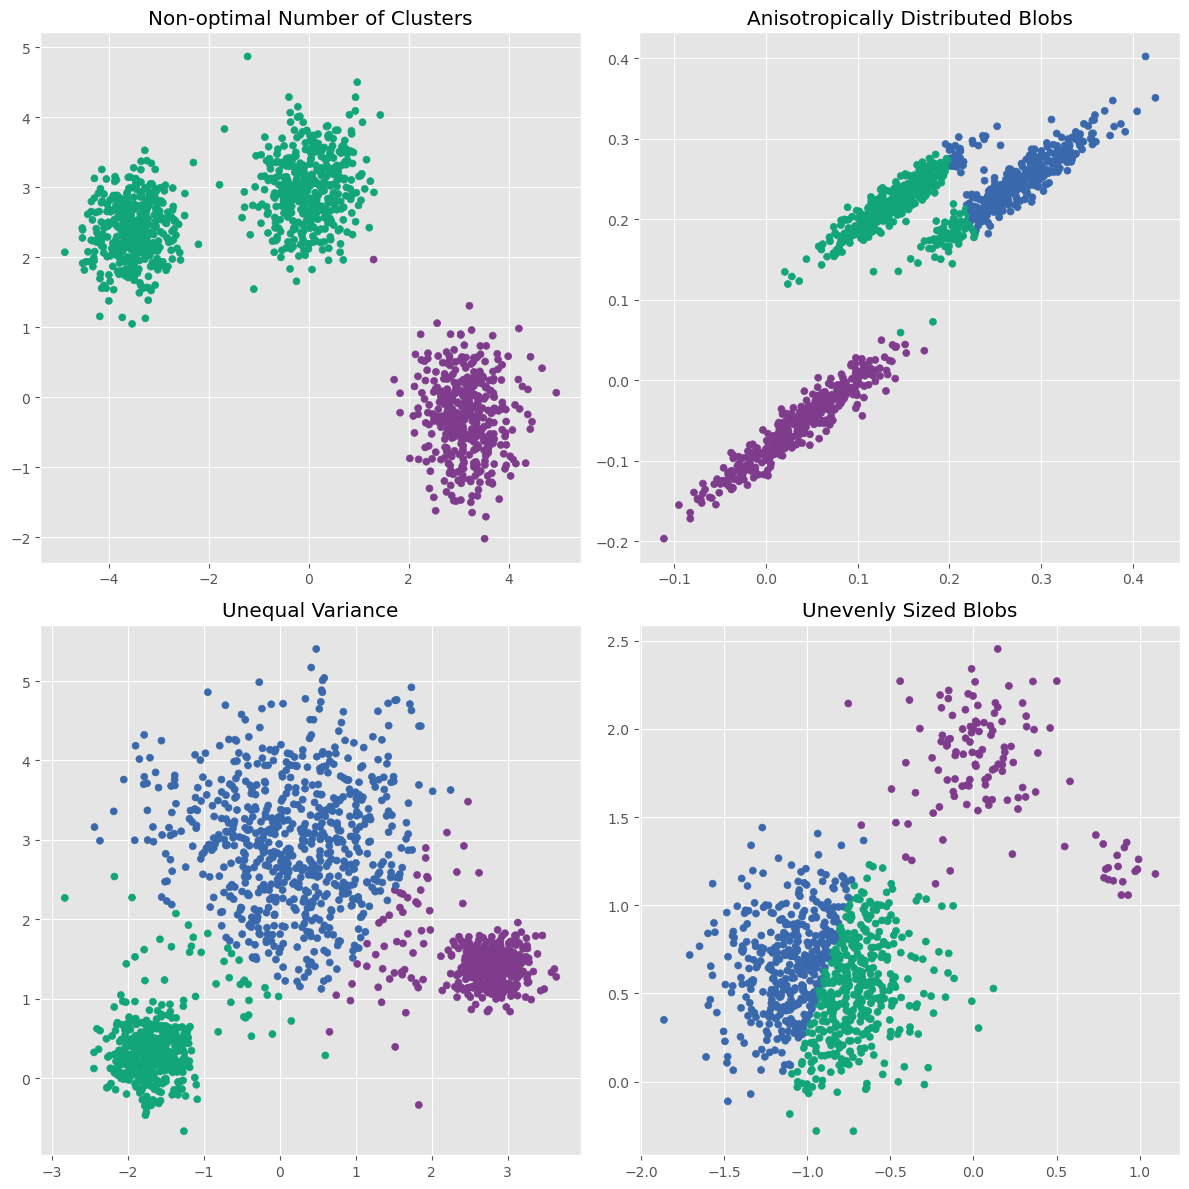

In [49]:
common_params = {
    "n_init": "auto",
    "random_state": 12345,
}

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

SIZE = 25
CMAP = cmaps.bold
cluster_colors = CMAP.colors[:3]

def plot_kmeans(ax, X, n_clusters, title):
    y_pred = KMeans(n_clusters=n_clusters, **common_params).fit_predict(X)
    colors = [cluster_colors[label] for label in y_pred]
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=SIZE)
    ax.set_title(title)

plot_kmeans(axs[0, 0], X, 2, "Non-optimal Number of Clusters")
plot_kmeans(axs[0, 1], X_aniso, 3, "Anisotropically Distributed Blobs")
plot_kmeans(axs[1, 0], X_varied, 3, "Unequal Variance")
plot_kmeans(axs[1, 1], X_filtered, 3, "Unevenly Sized Blobs")

plt.tight_layout()
plt.show()

This illustrates three important points:

* K-means works very well on simple blob-like clusters.
* It struggles when clusters are **stretched** rather than round.
* It can also struggle when clusters differ strongly in **variance** or **size**.

A further limitation is that K-means is sensitive to **outliers**, because cluster centers are based on averages. A few unusual points can pull a centroid away from where it would otherwise be.

Finally, the result can depend on the **initial placement** of the centroids. Modern implementations reduce this problem, for example through better initialization methods such as K-means++, but the issue does not disappear completely.

So K-means is a great first method to know and use, but it clearly cannot solve every clustering problem (spoiler: no single method can do that!).

## DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

K-means defines clusters through **centers**. DBSCAN takes a very different approach. It is a **density-based clustering algorithm**. Instead of looking for centroids, it looks for **dense regions of points**.

The full name is **Density-Based Spatial Clustering of Applications with Noise**, usually shortened to **DBSCAN**.

### How DBSCAN works

The central idea is that points inside a dense region should belong to the same cluster, while isolated points may be treated as noise.

DBSCAN uses two key parameters:

* `eps` (epsilon): the maximum distance within which points are considered neighbors
* `min_samples`: the minimum number of neighboring points required to define a dense region

The algorithm then works roughly as follows:

1. **Select a point**  
   Pick a data point and look at all points within distance `eps`.

2. **Check whether it is a core point**  
   If at least `min_samples` points lie within that neighborhood, the point is a **core point**.

3. **Expand the cluster**  
   Starting from this core point, DBSCAN expands the cluster by including neighboring points. If those neighboring points are themselves core points, the cluster grows further.

4. **Add border points**  
   Some points may lie close to a cluster without being dense enough to be core points themselves. These can still belong to the cluster as **border points**.

5. **Label noise**  
   Points that do not belong to any dense region are labeled as **noise**.


```{figure} ../images/fig_dbscan_sketch.png
:name: fig_dbscan

Illustrative diagram of the DBSCAN clustering process. For each data point, the algorithm iteratively searches points within a distance $\epsilon$, starting from a randomly chosen point (A) and then expanding (B). Points that are close but have fewer than required connections still belong to clusters (light blue point in panel C). Only if no such points are found, a point is labeled an outlier (gray dots, D).
```

This makes DBSCAN especially attractive when clusters are not nicely round or when the data contains clear outliers.

### DBSCAN on the same toy dataset

Using scikit-learn, DBSCAN can be applied very easily:

In [50]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=2).fit(data)

In [51]:
dbscan.labels_

array([ 0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  1,  1,  2, -1,
        3,  3,  3, -1,  3,  3,  3,  3,  3,  3,  3,  3,  3,  2,  3,  3,  3,
        3, -1,  4,  4, -1, -1,  4,  4,  4, -1,  4, -1,  4,  4,  4, -1,  4,
        4, -1,  4,  4,  4, -1,  4,  4, -1,  4])

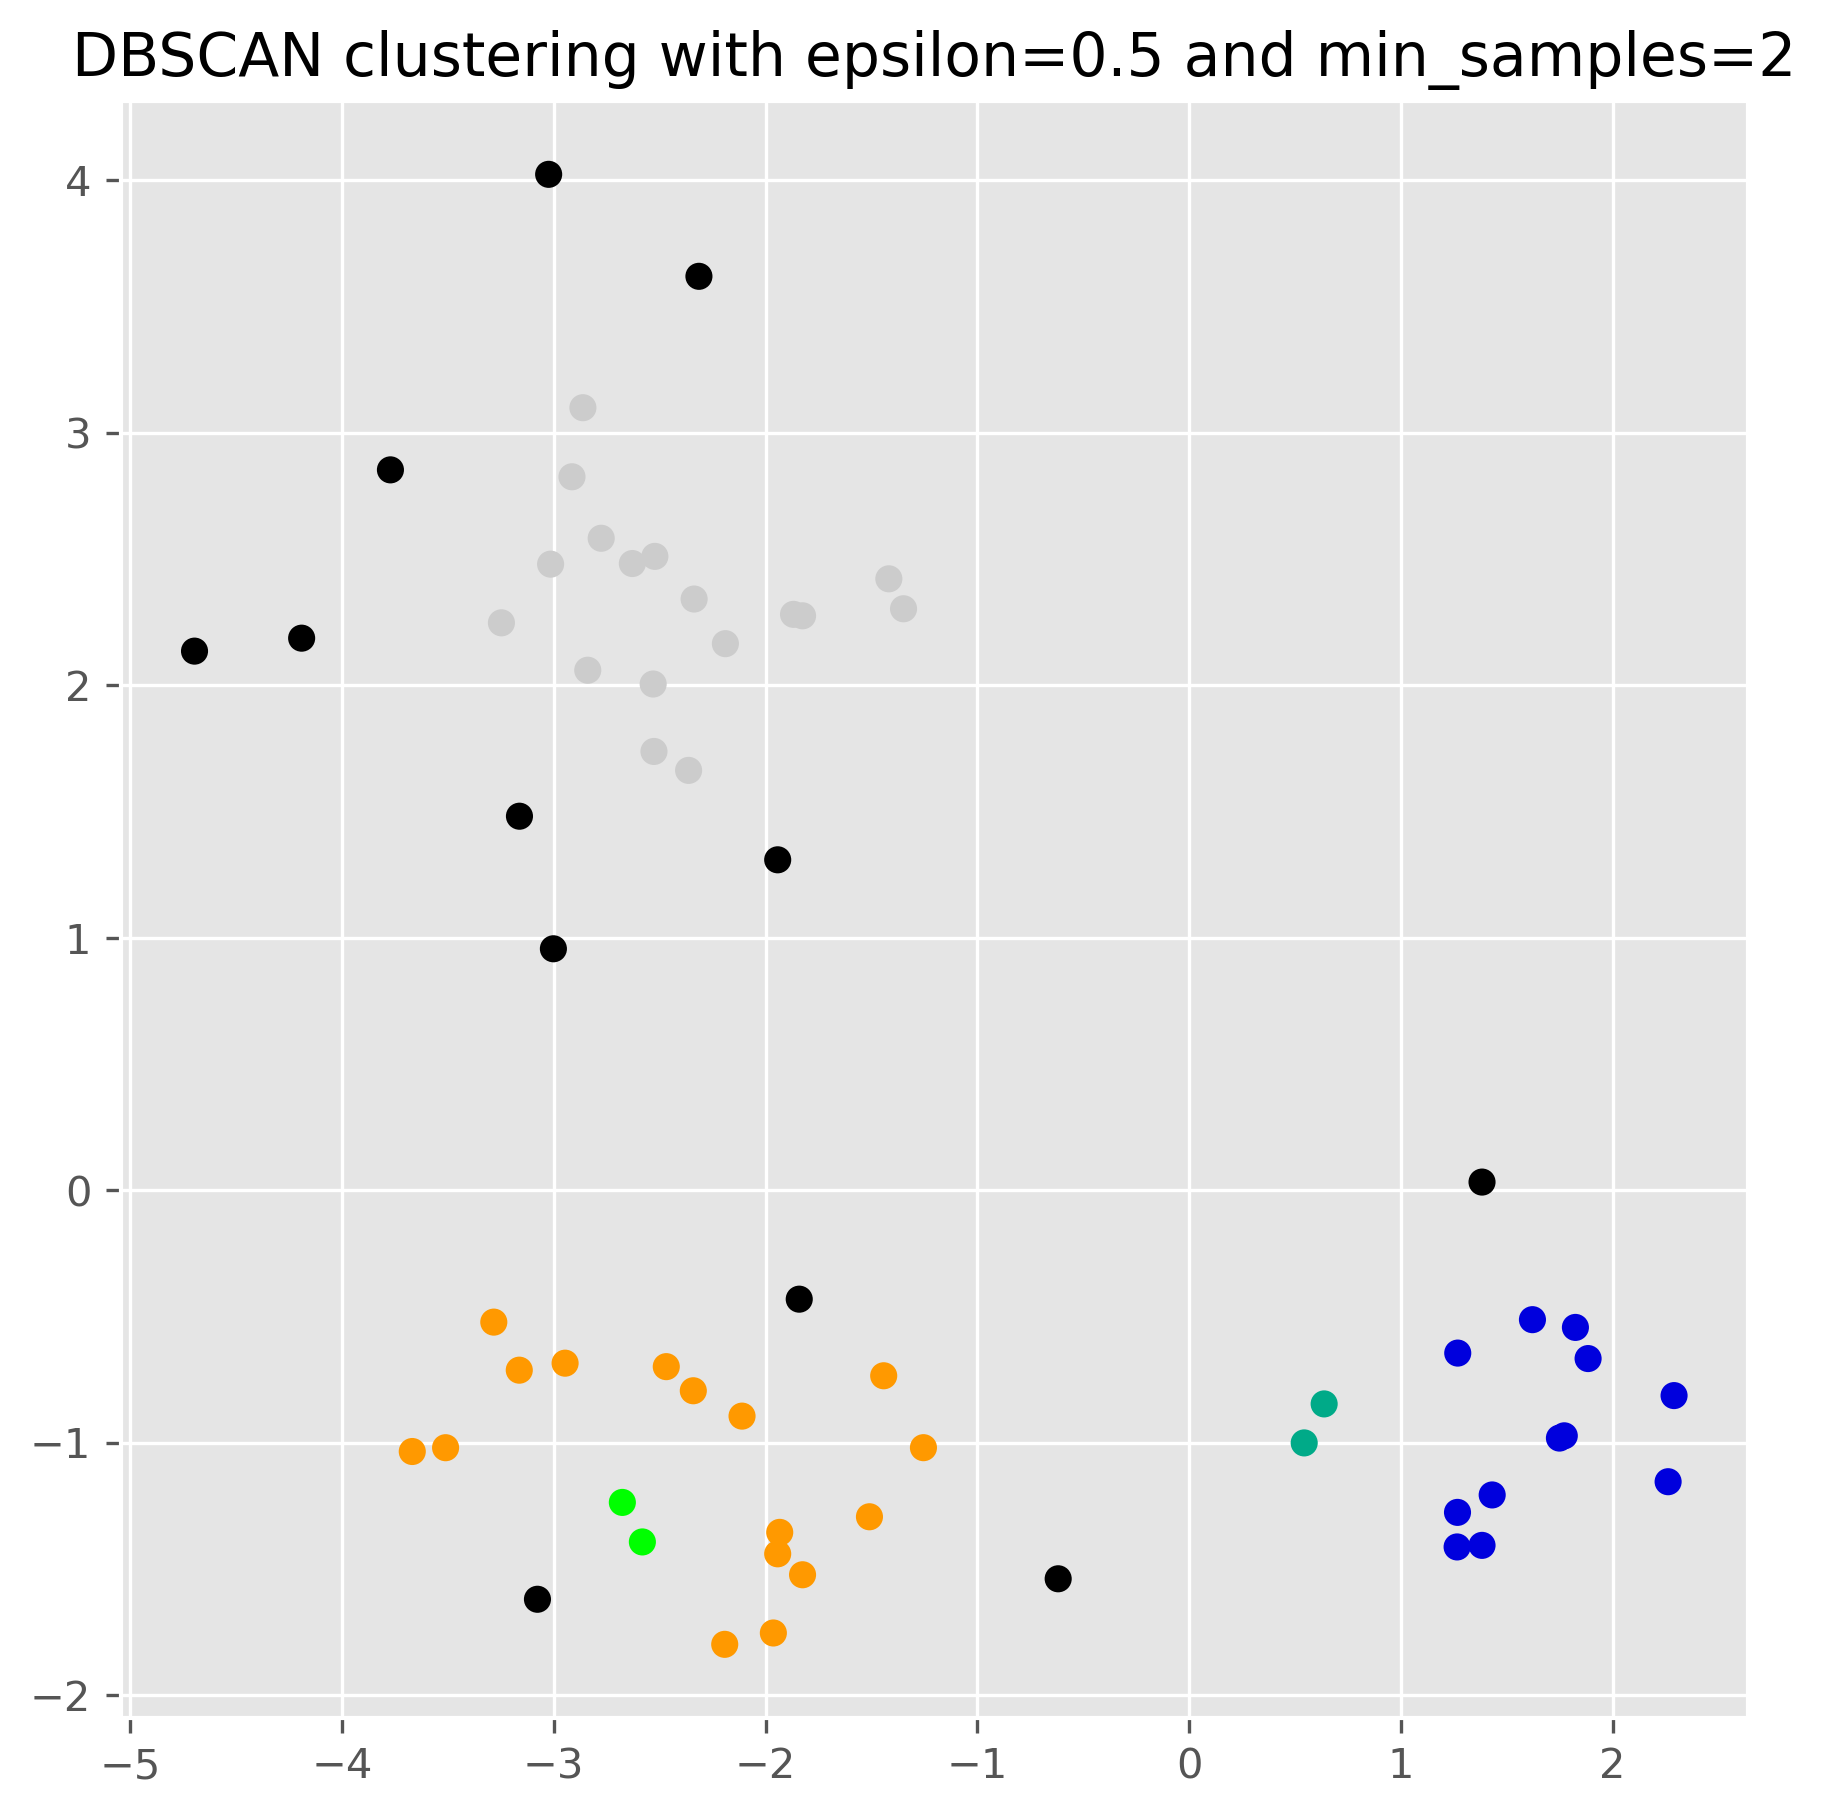

In [52]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

ax.scatter(data[:,0], data[:,1], c=dbscan.labels_, cmap="nipy_spectral")
ax.set_title("DBSCAN clustering with epsilon=0.5 and min_samples=2")
plt.show()

### The role of the parameters

For DBSCAN, the choice of `eps` and `min_samples` has a very strong effect on the result. In practice, `eps` is often especially influential.

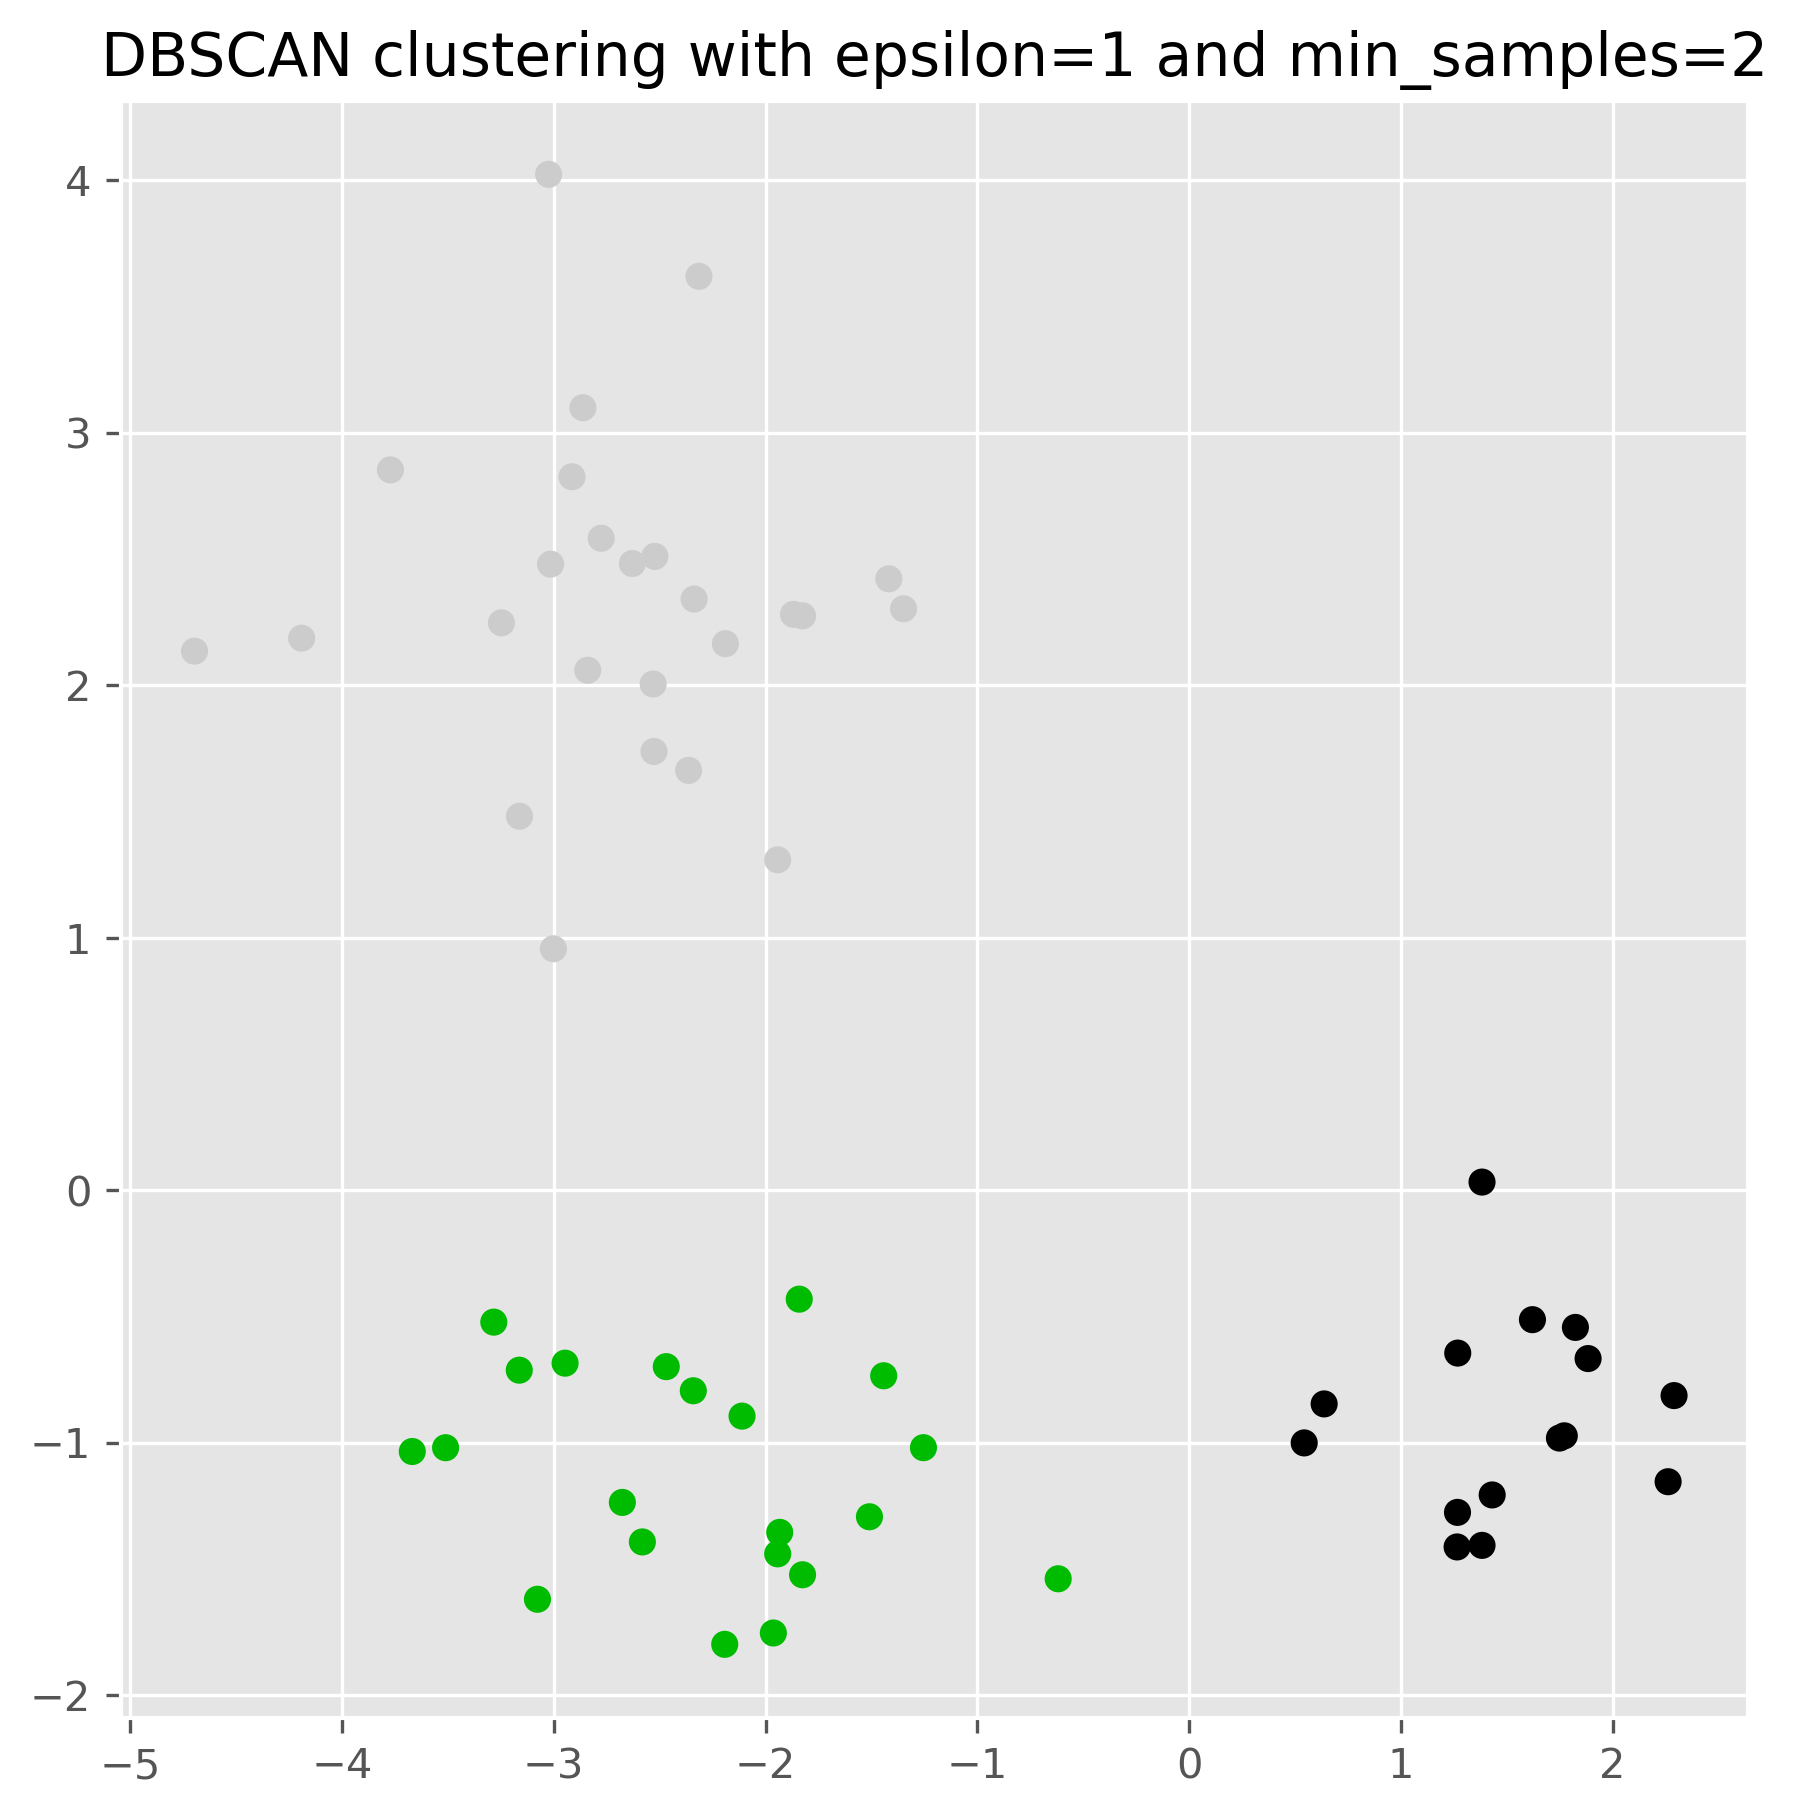

In [53]:
dbscan = DBSCAN(eps=1, min_samples=2).fit(data)

fig, ax = plt.subplots(figsize=(7, 7), dpi=300)

ax.scatter(data[:,0], data[:,1], c=dbscan.labels_, cmap="nipy_spectral")
ax.set_title("DBSCAN clustering with epsilon=1 and min_samples=2")
plt.show()

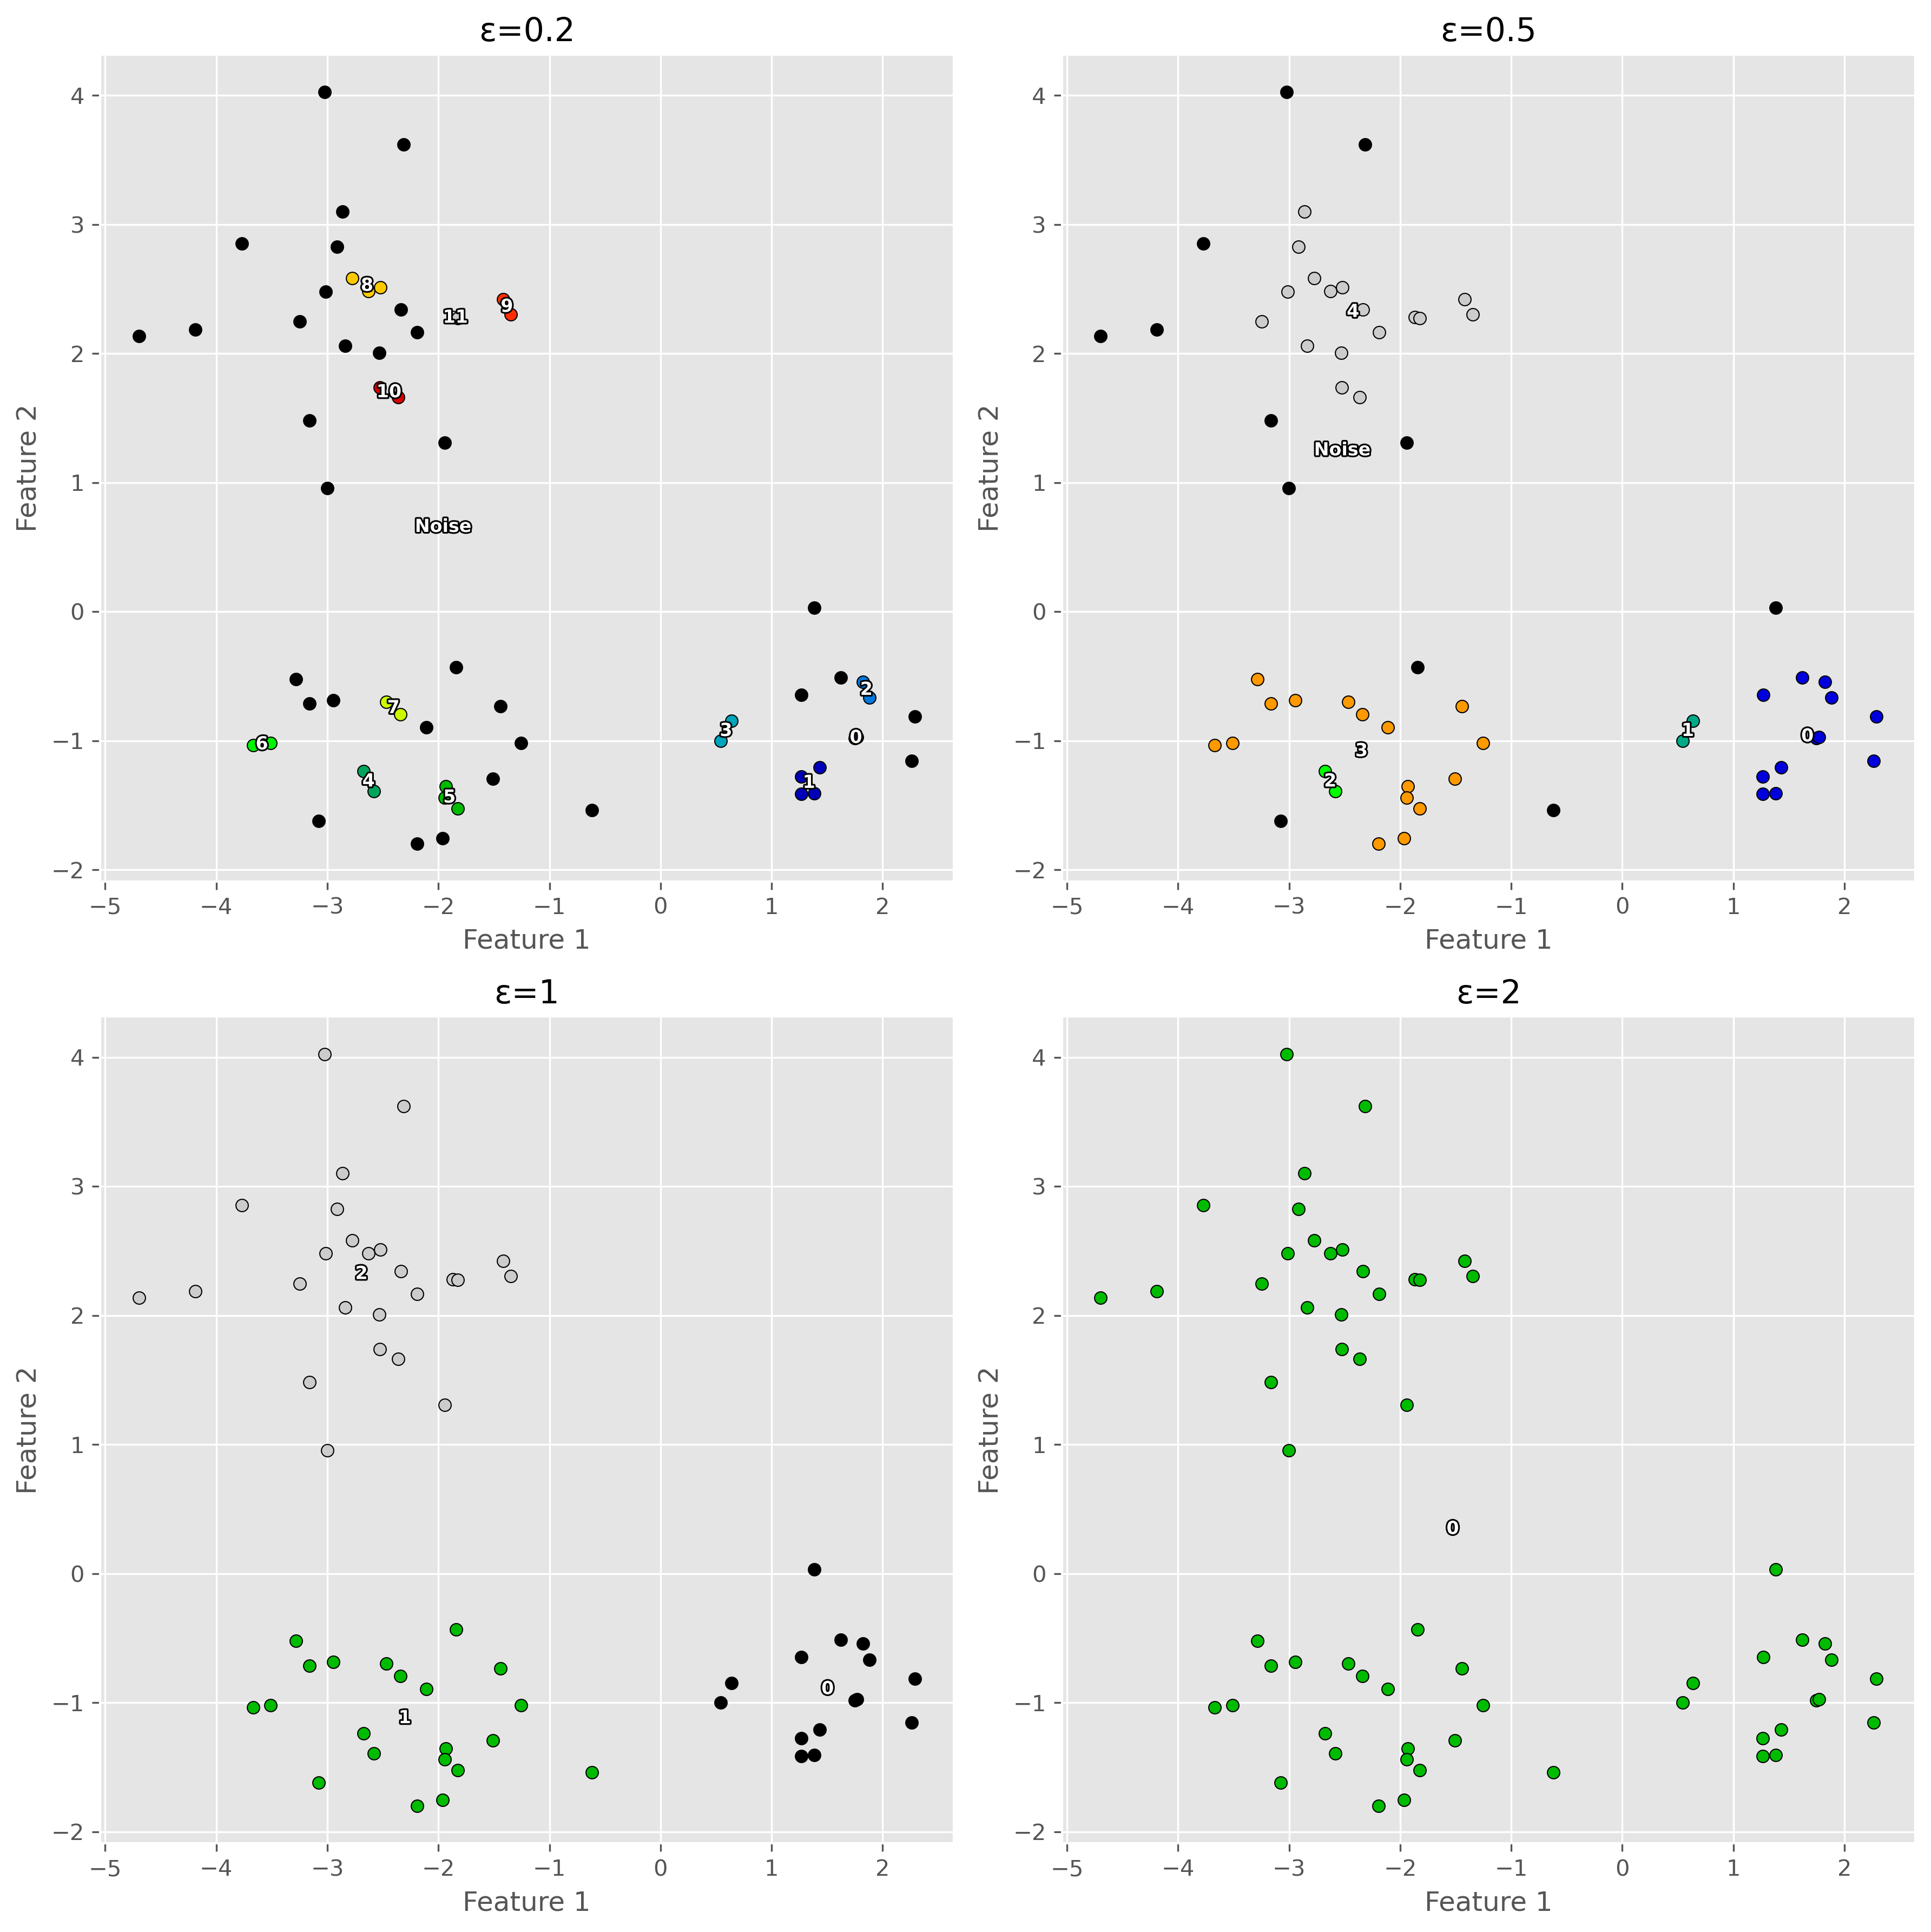

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as PathEffects
from sklearn.cluster import DBSCAN

fig, axes = plt.subplots(2, 2, figsize=(12, 12), dpi=300)
epsilons = [0.2, 0.5, 1, 2]

for i, eps in enumerate(epsilons):
    ax = axes[i // 2, i % 2]
    db = DBSCAN(eps=eps, min_samples=2).fit(data)
    labels = db.labels_
    uniq = sorted(set(labels))

    cmap = mpl.colormaps['nipy_spectral']
    
    # Plot each cluster and annotate its centroid
    for idx, lab in enumerate(uniq):
        pts = data[labels == lab]
        if pts.size == 0:
            continue
        # pick a distinct color by normalizing idx over number of clusters
        color = cmap(idx / (len(uniq) - 1)) if len(uniq) > 1 else cmap(0.5)
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=[color], edgecolor='k', s=30)
        
        # centroid text
        cen = pts.mean(axis=0)
        name = 'Noise' if lab == -1 else str(lab)
        txt = ax.text(cen[0], cen[1], name,
                      color='white', fontsize=8, fontweight='bold',
                      ha='center', va='center')
        # add black outline
        txt.set_path_effects([
            PathEffects.withStroke(linewidth=1.5, foreground='black')
        ])

    ax.set_title(f"ε={eps}")
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

This shows an important lesson: DBSCAN can work very well, but only if its parameters match the scale and density structure of the data reasonably well.

### Strengths of DBSCAN

DBSCAN has several attractive properties.

First, it does **not** require us to specify the number of clusters in advance. The clusters emerge from the data, depending on the density pattern.
Second, it can identify clusters of **arbitrary shape**, which makes it much more flexible than K-means in many situations.
Third, it can naturally identify **noise points** or outliers, rather than forcing every point into a cluster.

### Limitations of DBSCAN

DBSCAN also has important limitations.

Its biggest weakness is that it struggles when different clusters have very **different densities**. A single choice of `eps` and `min_samples` may work well for one part of the data and poorly for another.

The following example illustrates this problem.

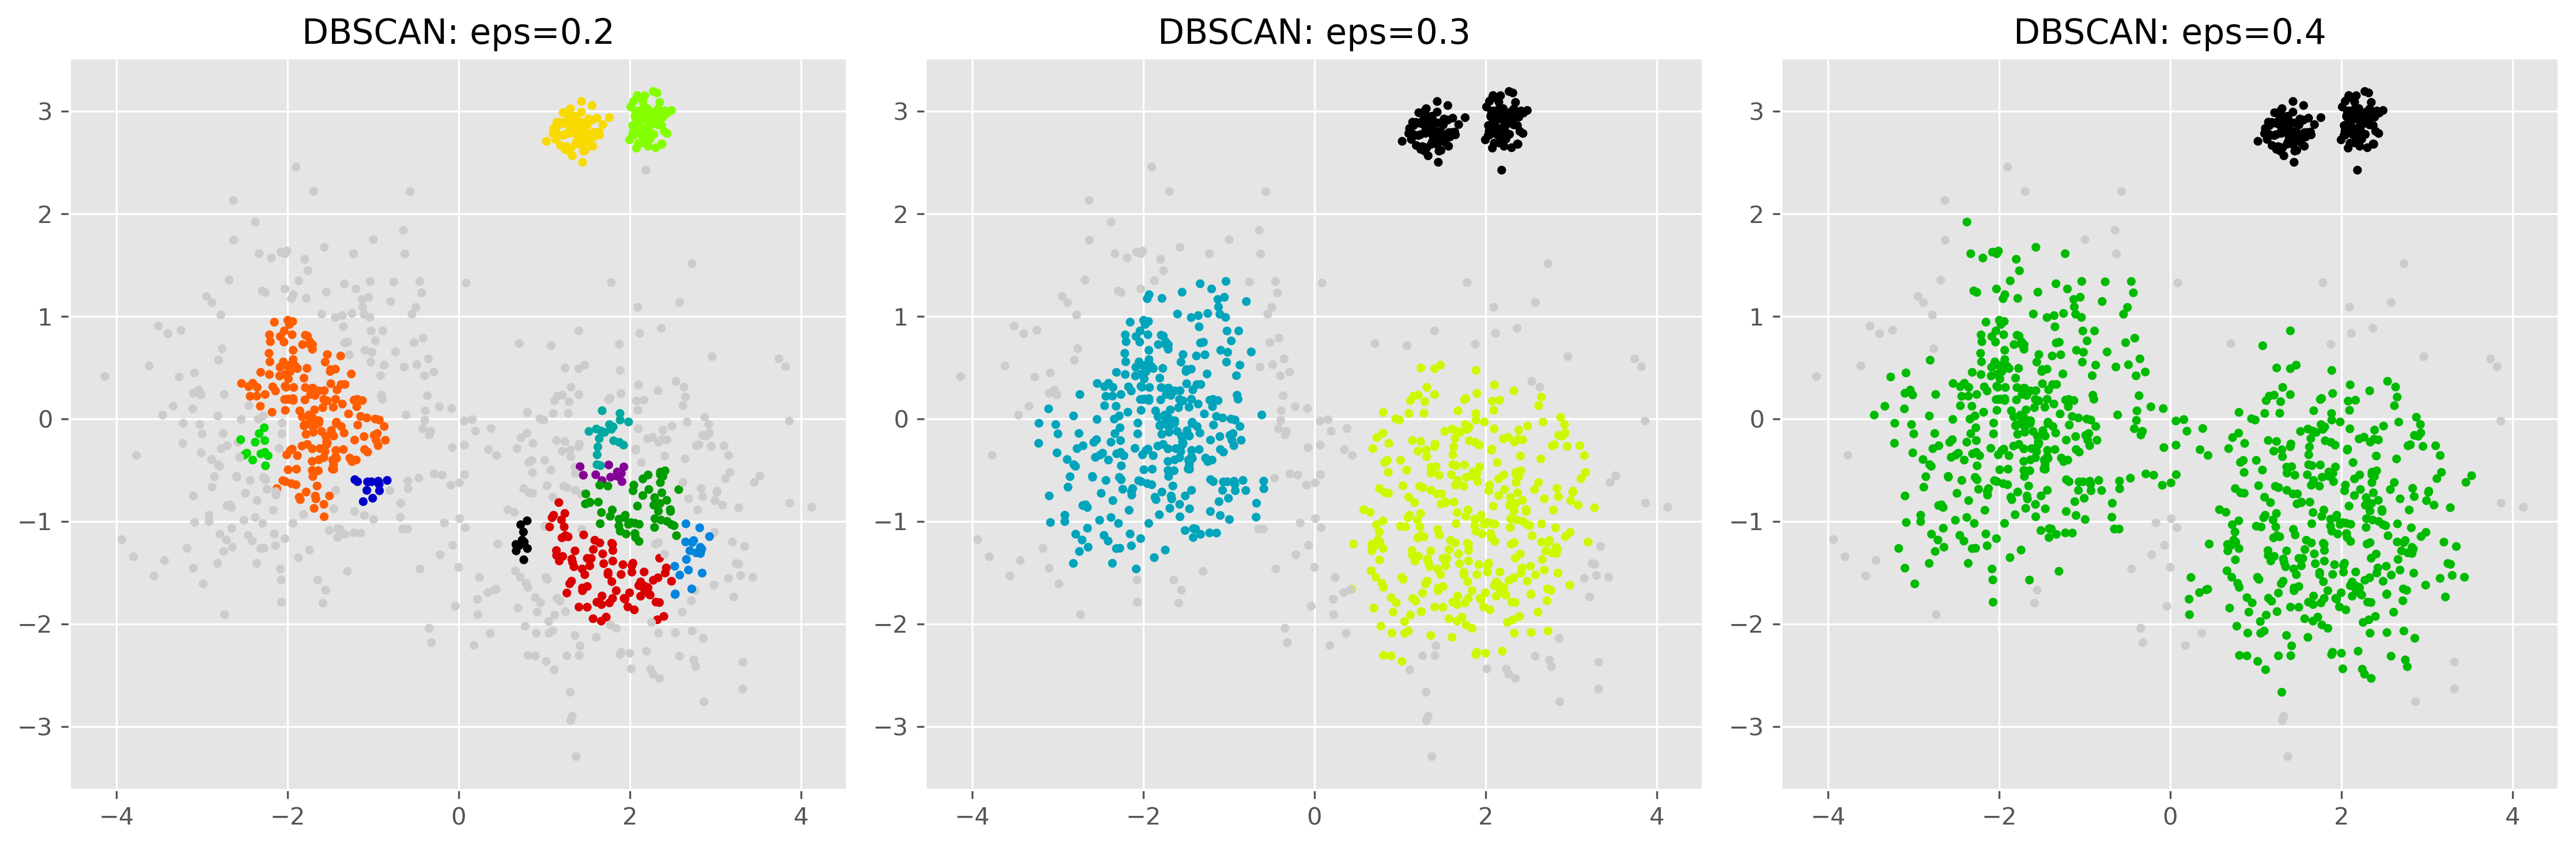

In [55]:
from sklearn.datasets import make_blobs

X_db, y_db = make_blobs(
    n_samples=[400, 400, 80, 80],
    centers=[(-1.8, 0), (1.7, -1), (1.4, 2.8), (2.2, 2.9)],
    cluster_std=[0.8, 0.8, 0.15, 0.15],
    random_state=1357
)

fig, axs = plt.subplots(1, 3, figsize=(15, 5), dpi=300)

# DBSCAN with smaller eps
eps = 0.2
min_samples = 10

db1 = DBSCAN(eps=eps, min_samples=min_samples).fit(X_db)
axs[0].scatter(X_db[:, 0], X_db[:, 1], c=db1.labels_, cmap="nipy_spectral_r", s=10)
axs[0].set_title(f"DBSCAN: eps={eps}")

# DBSCAN with medium eps
eps = 0.3
db1 = DBSCAN(eps=eps, min_samples=min_samples).fit(X_db)
axs[1].scatter(X_db[:, 0], X_db[:, 1], c=db1.labels_, cmap="nipy_spectral_r", s=10)
axs[1].set_title(f"DBSCAN: eps={eps}")

# DBSCAN with larger eps
eps = 0.4
db2 = DBSCAN(eps=eps, min_samples=min_samples).fit(X_db)
axs[2].scatter(X_db[:, 0], X_db[:, 1], c=db2.labels_, cmap="nipy_spectral_r", s=10)
axs[2].set_title(f"DBSCAN: eps={eps}")

plt.tight_layout()
plt.show()

Here we see the central problem. With a small `eps`, the sparser clusters may be fragmented or partly labeled as noise. With a larger `eps`, denser and sparser regions may be merged too aggressively. In the example shown here, for instance, we cannot find an `eps`-setting able to properly detect both the two more distributed clusters and the two very dense clusters. This shows that DBSCAN can work very well when the density structure is suitable, but is generally less reliable when densities vary strongly across the dataset.

A second limitation is that DBSCAN becomes more difficult in **high-dimensional spaces**, where distance relationships become less informative. Like many clustering methods, it works best when the feature space has been chosen and scaled carefully.

## Clustering on real data

So far, we have mainly used toy datasets to understand how clustering algorithms behave. Real datasets are usually messier. Before clustering them, we often need to think carefully about preprocessing, feature selection, scale, and the actual meaning of the variables.

### Data preprocessing

Preprocessing is especially important for clustering because many clustering algorithms depend directly on **distance calculations**. If the features are not prepared in a meaningful way, the clustering result may become misleading. The following example shows what can go wrong if the data is not processed in the correct way.





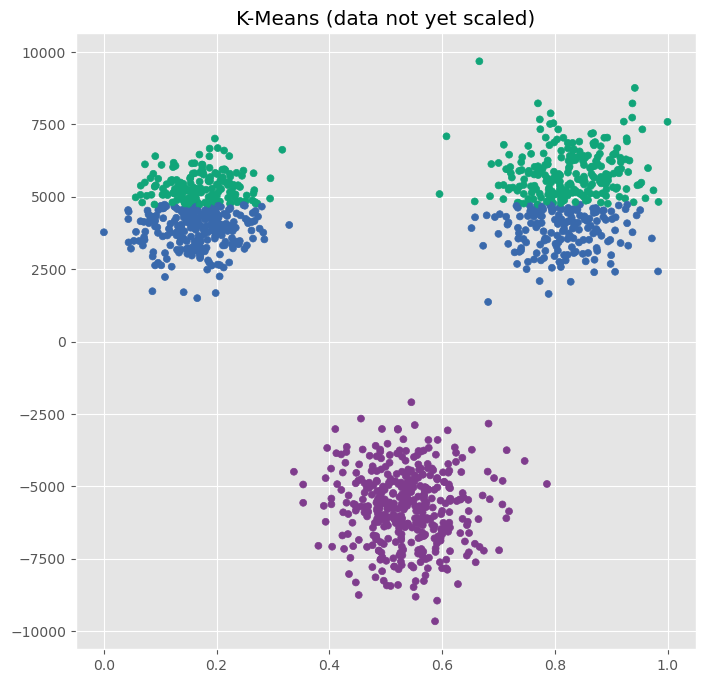

In [58]:
np.random.seed(7)
NUM_PER_CLUSTER = 400

# 1) Three well-separated blob-like clusters
clusters_base = [
    (NUM_PER_CLUSTER, 0.4, 0.4, -2.5,  1.8),
    (NUM_PER_CLUSTER, 0.5, 0.50,  2.2,  2.0),
    (NUM_PER_CLUSTER, 0.50, 0.5,  0.2, -2.3),
]

X_parts = []
for i, (n_points, x_scale, y_scale, x_offset, y_offset) in enumerate(clusters_base):
    xpts = np.random.randn(n_points) * x_scale + x_offset
    ypts = np.random.randn(n_points) * y_scale + y_offset
    X_parts.append(np.vstack((xpts, ypts)).T)

X = np.vstack(X_parts)
X[:, 0] += np.abs(X[:, 0].min())
X[:, 0] /= X[:, 0].max()
X[:, 1] *= 2_500


# Create plot
fig, ax = plt.subplots(figsize=(8, 8))
plot_kmeans(ax, X, n_clusters=3, title="K-Means (data not yet scaled)")

In the scatter plot, we clearly recognize three clusters, but K-Means apparently fails.

The underlying reason is the **feature scale** of the data we used here. As we see on the x and y-axis, one feature ranges from 0 to 1, while another ranges from -10000 to 10000. If we cluster the raw data directly, the second feature will dominate most distance calculations, whether or not that is actually justified. This is why methods such as K-means often require **standardization**.

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(X)

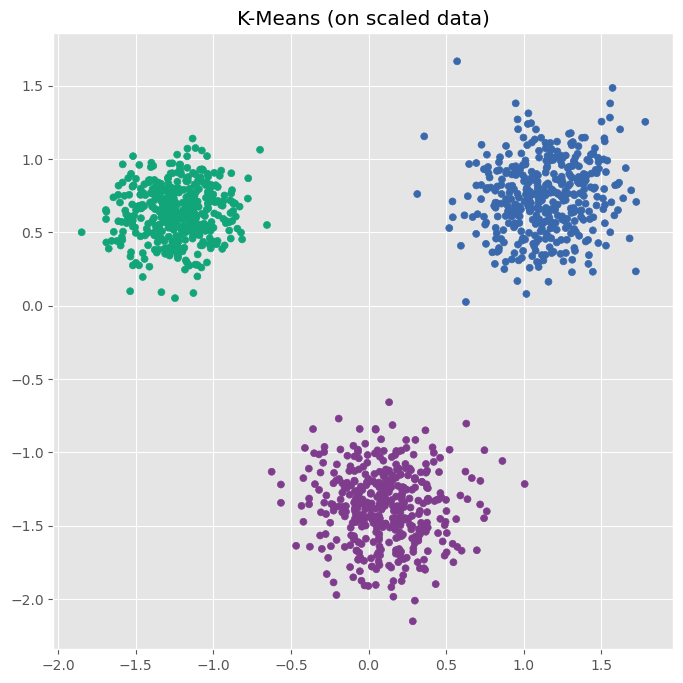

In [60]:
# Create plot
fig, ax = plt.subplots(figsize=(8, 8))
plot_kmeans(ax, data_scaled, n_clusters=3, title="K-Means (on scaled data)")

After standardizing the data, K-Means indentifies the three clusters as we would expect.

Another important preprocessing step is dealing with **missing values**. Most clustering algorithms cannot handle missing entries directly. Depending on the situation, we may need to remove incomplete rows, impute missing values, or drop variables with too many missing entries.

We also need to think carefully about **outliers**. For K-means in particular, outliers can have a strong influence because cluster centers are based on means. DBSCAN is often more robust here, but even DBSCAN can be affected if the scale of the data is distorted by extreme values.

Data preprocessing for clustering also includes checking **data types** and **feature meaning**. A variable that is technically numeric is not automatically suitable for Euclidean-distance-based clustering. Postal codes, IDs, and arbitrary category encodings are classic examples: they may look numeric, but treating them as continuous distances can be highly misleading.

Finally, preprocessing sometimes includes **dimensionality reduction**. In high-dimensional spaces, many points start to appear similarly far away from one another, which can make distance-based clustering much harder. Methods such as PCA can help reduce dimensionality while retaining important structure. We will return to this in later chapters (see {ref}`ch_dimensionality`).

### Choosing meaningful features

Feature selection is especially important in clustering because clustering is an **unsupervised** task. There is no target variable telling the algorithm what we actually care about. So the choice of features strongly shapes what kind of clusters we will find.

If we cluster customers by age and income, we may get very different groups than if we cluster them by product preferences and website behavior. Neither result is automatically “wrong.” They simply reflect different questions.
This is why clustering is often best understood as a dialogue between the **data**, the **algorithm**, and the **question we ask**.

### A small real-data example

In practice, clustering is often applied not to synthetic point clouds, but to real tabular datasets with many variables. This brings us back to a recurring theme in data science: before applying a sophisticated method, we usually need to understand and prepare the data first.

For example, on a real customer dataset we might first:

* remove or impute missing values,
* choose only meaningful behavioral variables,
* standardize numerical features,
* and possibly reduce dimensionality.

Only then does clustering really become informative.

## More on Clustering

Clustering is one of the central exploratory tools in data science. It helps us organize data into groups, uncover hidden structure, summarize complex datasets, and sometimes identify anomalies.

In this chapter, we looked at two important clustering methods.  
**K-means** is a centroid-based method that is simple, intuitive, and often computationally efficient. It works especially well when clusters are compact, roughly spherical, and of similar size. But it requires choosing the number of clusters in advance and can struggle when clusters are elongated, unevenly sized, or strongly affected by outliers.

**DBSCAN** is a density-based method that can find irregularly shaped clusters and naturally identify noise points. It does not require choosing the number of clusters beforehand. However, it depends strongly on its parameters and can struggle when clusters differ strongly in density.

The main lesson is not that one of these algorithms is “best.” The main lesson is that different clustering algorithms define clusters differently. Good clustering therefore depends not only on running an algorithm, but on understanding the data, the assumptions of the method, and the purpose of the analysis.

K-means and DBSCAN are only two of many clustering approaches. In the next chapter, we will extend the picture by looking at **Gaussian mixture models**, which allow soft cluster membership, and **hierarchical clustering**, which builds a tree-like structure of nested groups.


For a broader overview of clustering methods, the [scikit-learn clustering documentation](https://scikit-learn.org/stable/modules/clustering.html) is an excellent place to explore further examples and compare algorithms.

If you want a more general review article, one useful starting point is:
- "A review of clustering techniques and developments" by Amit Saxena and Mukesh Prasad and Akshansh Gupta and Neha Bharill and Om Prakash Patel and Aruna Tiwari and Meng Joo Er and Weiping Ding and Chin-Teng Lin, 2017, Neurocomputing, Vol.267, https://doi.org/10.1016/j.neucom.2017.06.053 {cite}`saxena2017review`
